Data-Driven Financial Forecasting Using Traditional and Machine Learning Models

This notebook develops a data-driven forecasting framework using quarterly financial statement data from the SEC Financial Statement Data Sets and macroeconomic indicators from FRED.

The main objective is to compare traditional forecasting approaches and machine learning models in predicting two key financial statement items:

- Operating Income
- Operating Cash Flow

The analysis focuses on a selected sample of U.S.-listed companies from two sectors: Technology and Manufacturing. The training period covers 2018–2024, while 2025 is used as the out-of-sample test period.

Research Design Summary

- Sample: 5 Technology firms and 5 Manufacturing firms
- Primary data source: SEC Financial Statement Data Sets
- Secondary data source: FRED macroeconomic indicators
- Training period: 2018–2024
- Test period: 2025
- Target variables: Operating Income and Operating Cash Flow
- Models: Lag-1 Baseline, 4-Quarter Moving Average, Linear Regression, Random Forest, and XGBoost
- Evaluation metrics: MAE, RMSE, R², Bias, and MASE
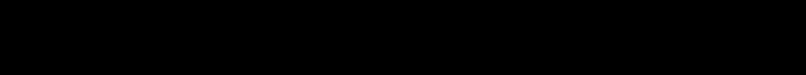

Library Imports and Global Settings

This section imports the Python libraries used for data processing, visualization, macroeconomic data retrieval, and machine learning model estimation.

SEC Data Download and File Setup

The SEC Financial Statement Data Sets are downloaded for each quarter between 2018 and 2025. These files contain standardized financial statement information reported by U.S.-listed companies.

In [77]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import requests
import zipfile
from pathlib import Path
from pandas_datareader import data as web
import os
from pathlib import Path

import requests
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
try:
    from xgboost import XGBRegressor
    xgboost_available = True
except ImportError:
    xgboost_available = False
    print("xgboost is not installed. Install it with: pip install xgboost")
from io import BytesIO

In [78]:
BASE_URL = "https://www.sec.gov/files/dera/data/financial-statement-data-sets"
RAW_DIR = Path("data/Alp-Intro Data-Science-Project_files")
RAW_DIR.mkdir(parents=True, exist_ok=True)

years = range(2018, 2026)
quarters = range(1, 5)

headers = {
    "User-Agent": "alpdemiroz1994@gmail.com dissertation research"
}

for year in years:
    for q in quarters:
        file_name = f"{year}q{q}.zip"
        url = f"{BASE_URL}/{file_name}"
        output_path = RAW_DIR / file_name

        if output_path.exists():
            print(f"Already exists: {file_name}")
            continue

        print(f"Downloading {file_name}...")
        response = requests.get(url, headers=headers, timeout=60)

        if response.status_code == 200:
            output_path.write_bytes(response.content)
            print(f"Saved: {output_path}")
        else:
            print(f"Failed: {file_name}, status code: {response.status_code}")

Already exists: 2018q1.zip
Already exists: 2018q2.zip
Already exists: 2018q3.zip
Already exists: 2018q4.zip
Already exists: 2019q1.zip
Already exists: 2019q2.zip
Already exists: 2019q3.zip
Already exists: 2019q4.zip
Already exists: 2020q1.zip
Already exists: 2020q2.zip
Already exists: 2020q3.zip
Already exists: 2020q4.zip
Already exists: 2021q1.zip
Already exists: 2021q2.zip
Already exists: 2021q3.zip
Already exists: 2021q4.zip
Already exists: 2022q1.zip
Already exists: 2022q2.zip
Already exists: 2022q3.zip
Already exists: 2022q4.zip
Already exists: 2023q1.zip
Already exists: 2023q2.zip
Already exists: 2023q3.zip
Already exists: 2023q4.zip
Already exists: 2024q1.zip
Already exists: 2024q2.zip
Already exists: 2024q3.zip
Already exists: 2024q4.zip
Already exists: 2025q1.zip
Already exists: 2025q2.zip
Already exists: 2025q3.zip
Already exists: 2025q4.zip


Sample Selection and Variable Definition

The final sample consists of five Technology firms and five Manufacturing firms. Firms were selected based on sector relevance and the availability of quarterly observations for both target variables: Operating Income and Operating Cash Flow.

In [79]:
company_name_map = {
    # Technology
    320193: "APPLE INC",
    789019: "MICROSOFT CORP",
    1045810: "NVIDIA CORP",
    50863: "INTEL CORP",
    796343: "ADOBE INC",

    # Manufacturing
    49826: "ILLINOIS TOOL WORKS INC",
    26172: "CUMMINS INC",
    66740: "3M CO",
    1659166: "FORTIVE CORP",
    832101:  "IDEX CORP"
}

target_and_feature_tags = [

    "OperatingIncomeLoss",
    "NetCashProvidedByUsedInOperatingActivities",

    "RevenueFromContractWithCustomerExcludingAssessedTax",
    "Revenues",
    "SalesRevenueNet",

    "NetIncomeLoss",
    "Assets",
    "Liabilities",
    "CashAndCashEquivalentsAtCarryingValue",
    "StockholdersEquity",

    "CostOfRevenue",
    "CostOfGoodsAndServicesSold",
    "SellingGeneralAndAdministrativeExpense",
    "ResearchAndDevelopmentExpense",
    "OperatingExpenses"
]

sector_map = {
    # Technology
    320193: "Technology",
    789019: "Technology",
    1045810: "Technology",
    50863: "Technology",
    796343: "Technology",

    # Manufacturing
    49826: "Manufacturing",
    26172: "Manufacturing",
    66740: "Manufacturing",
    1659166: "Manufacturing",
    832101: "Manufacturing",
}

SEC Data Loading and Filtering

Because the SEC files are large, the data are read in chunks. The custom reader filters the dataset by selected CIKs and XBRL tags before merging the financial values with company-level filing information.

In [80]:
def read_sec_quarter_filtered(
    zip_path: Path,
    company_name_map: list,
    selected_tags: list,
    chunksize: int = 100_000
) -> pd.DataFrame:

    quarter_label = zip_path.stem

    with zipfile.ZipFile(zip_path, "r") as z:

        sub_usecols = [
            "adsh", "cik", "name", "sic", "fy", "fp", "form", "period", "filed"
        ]

        sub = pd.read_csv(
            z.open("sub.txt"),
            sep="\t",
            usecols=lambda c: c in sub_usecols,
            dtype={
                "adsh": "string",
                "cik": "Int64",
                "name": "string",
                "sic": "Int64",
                "fy": "Int64",
                "fp": "string",
                "form": "string",
                "period": "Int64",
                "filed": "Int64"
            },
            low_memory=False
        )

        sub = sub[sub["cik"].isin(company_name_map)].copy()

        if sub.empty:
            return pd.DataFrame()

        selected_adsh = set(sub["adsh"].dropna().astype(str))

        num_usecols = ["adsh", "tag", "ddate", "qtrs", "uom", "value", "coreg"]

        filtered_chunks = []

        for chunk in pd.read_csv(
            z.open("num.txt"),
            sep="\t",
            usecols=lambda c: c in num_usecols,
            dtype={
                "adsh": "string",
                "tag": "string",
                "ddate": "Int64",
                "qtrs": "Int64",
                "uom": "string",
                "value": "float64",
                "coreg": "string"
            },
            chunksize=chunksize,
            low_memory=False
        ):
            chunk = chunk[
                chunk["adsh"].isin(selected_adsh) &
                chunk["tag"].isin(selected_tags)
            ].copy()

            if "coreg" in chunk.columns:
                chunk = chunk[chunk["coreg"].isna()]

            if not chunk.empty:
                filtered_chunks.append(chunk)

        if not filtered_chunks:
            return pd.DataFrame()

        num_filtered = pd.concat(filtered_chunks, ignore_index=True)

        merged = num_filtered.merge(sub, on="adsh", how="left")
        merged["source_quarter"] = quarter_label

        return merged

Exporting SEC Dataset
All quarterly files are filtered and concatenated into sec_long, the main long format SEC dataset.

In [81]:
RAW_DIR = Path("data/Alp-Intro Data-Science-Project_files")

all_files = sorted(RAW_DIR.glob("*.zip"))

sec_long_parts = []

for file in all_files:
    print(f"Reading {file.name}...")

    try:
        df_q = read_sec_quarter_filtered(
            zip_path=file,
            company_name_map=company_name_map,
            selected_tags=target_and_feature_tags,
            chunksize=100_000
        )

        if not df_q.empty:
            sec_long_parts.append(df_q)
            print(f"  kept rows: {len(df_q):,}")
        else:
            print("  no relevant rows")

    except Exception as e:
        print(f"Error reading {file.name}: {e}")

sec_long = pd.concat(sec_long_parts, ignore_index=True)

print("Final shape:", sec_long.shape)
sec_long.head()

Reading 2018q1.zip...
  kept rows: 1,346
Reading 2018q2.zip...
  kept rows: 1,060
Reading 2018q3.zip...
  kept rows: 1,332
Reading 2018q4.zip...
  kept rows: 1,273
Reading 2019q1.zip...
  kept rows: 1,575
Reading 2019q2.zip...
  kept rows: 1,098
Reading 2019q3.zip...
  kept rows: 1,599
Reading 2019q4.zip...
  kept rows: 1,434
Reading 2020q1.zip...
  kept rows: 1,597
Reading 2020q2.zip...
  kept rows: 1,086
Reading 2020q3.zip...
  kept rows: 1,583
Reading 2020q4.zip...
  kept rows: 1,445
Reading 2021q1.zip...
  kept rows: 1,592
Reading 2021q2.zip...
  kept rows: 1,106
Reading 2021q3.zip...
  kept rows: 1,568
Reading 2021q4.zip...
  kept rows: 1,434
Reading 2022q1.zip...
  kept rows: 1,434
Reading 2022q2.zip...
  kept rows: 1,117
Reading 2022q3.zip...
  kept rows: 1,475
Reading 2022q4.zip...
  kept rows: 1,325
Reading 2023q1.zip...
  kept rows: 1,380
Reading 2023q2.zip...
  kept rows: 1,005
Reading 2023q3.zip...
  kept rows: 1,429
Reading 2023q4.zip...
  kept rows: 1,262
Reading 2024q1.z

,adsh,tag,ddate,qtrs,uom,coreg,value,cik,name,sic,form,period,fy,fp,filed,source_quarter
0,0001564590-18-001129,SalesRevenueNet,20171231,2,USD,<NA>,2.579900e+10,789019,MICROSOFT CORP,7372,10-Q,20171231,2018,Q2,20180131,2018q1
1,0000049826-18-000017,OperatingIncomeLoss,20161231,4,USD,<NA>,3.700000e+08,49826,ILLINOIS TOOL WORKS INC,3560,10-K,20171231,2017,FY,20180215,2018q1
2,0001564590-18-001129,SalesRevenueNet,20171231,2,USD,<NA>,9.482000e+09,789019,MICROSOFT CORP,7372,10-Q,20171231,2018,Q2,20180131,2018q1
3,0000026172-18-000011,SalesRevenueNet,20151231,4,USD,<NA>,3.745000e+09,26172,CUMMINS INC,3510,10-K,20171231,2017,FY,20180214,2018q1
4,0000832101-18-000019,Assets,20161231,0,USD,<NA>,1.175030e+08,832101,IDEX CORP /DE/,3561,10-K,20171231,2017,FY,20180222,2018q1


In [82]:
sec_long.shape

(43569, 16)

In [83]:
sec_long.info()

<class 'pandas.DataFrame'>
RangeIndex: 43569 entries, 0 to 43568
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   adsh            43569 non-null  string 
 1   tag             43569 non-null  string 
 2   ddate           43569 non-null  Int64  
 3   qtrs            43569 non-null  Int64  
 4   uom             43569 non-null  string 
 5   coreg           0 non-null      string 
 6   value           43569 non-null  float64
 7   cik             43569 non-null  Int64  
 8   name            43569 non-null  string 
 9   sic             43569 non-null  Int64  
 10  form            43569 non-null  string 
 11  period          43569 non-null  Int64  
 12  fy              43336 non-null  Int64  
 13  fp              43336 non-null  string 
 14  filed           43569 non-null  Int64  
 15  source_quarter  43569 non-null  str    
dtypes: Int64(7), float64(1), str(1), string(7)
memory usage: 5.6 MB


In [84]:
sec_long.describe().T

,count,mean,std,min,25%,50%,75%,max
ddate,43569.0,20206959.242787,24432.286146,20141130.0,20190331.0,20210331.0,20230331.0,20251031.0
qtrs,43569.0,1.715027,1.429467,0.0,1.0,1.0,3.0,4.0
value,43569.0,11633544639.560238,34891539743.020348,-46373000000.0,166300000.0,1263900000.0,7454000000.0,636351000000.0
cik,43569.0,667584.934472,586953.854441,26172.0,50863.0,789019.0,1045810.0,1659166.0
sic,43569.0,4409.525511,1492.543387,3510.0,3561.0,3674.0,3841.0,7372.0
period,43569.0,20213385.947669,23228.810832,20171130.0,20191231.0,20210930.0,20231231.0,20251031.0
fy,43336.0,2021.365516,2.362959,2017.0,2019.0,2021.0,2023.0,2026.0
filed,43569.0,20215664.814478,22801.959236,20180122.0,20200124.0,20211102.0,20240126.0,20251119.0


In [85]:
sec_long["tag"].value_counts()

tag
RevenueFromContractWithCustomerExcludingAssessedTax    11067
Revenues                                                9552
StockholdersEquity                                      4943
OperatingIncomeLoss                                     4885
CashAndCashEquivalentsAtCarryingValue                   2564
NetIncomeLoss                                           1753
Assets                                                  1512
CostOfGoodsAndServicesSold                              1508
ResearchAndDevelopmentExpense                           1374
SalesRevenueNet                                          989
CostOfRevenue                                            948
SellingGeneralAndAdministrativeExpense                   815
NetCashProvidedByUsedInOperatingActivities               745
OperatingExpenses                                        460
Liabilities                                              454
Name: count, dtype: Int64

In [86]:
sec_long.groupby(["tag", "qtrs"]).size().sort_values(ascending=False).head(50)

tag                                                  qtrs
StockholdersEquity                                   0       4943
RevenueFromContractWithCustomerExcludingAssessedTax  1       4875
Revenues                                             1       4489
RevenueFromContractWithCustomerExcludingAssessedTax  4       3042
CashAndCashEquivalentsAtCarryingValue                0       2564
OperatingIncomeLoss                                  1       2215
Revenues                                             4       2037
RevenueFromContractWithCustomerExcludingAssessedTax  2       1577
                                                     3       1573
Revenues                                             3       1564
Assets                                               0       1512
Revenues                                             2       1461
OperatingIncomeLoss                                  4       1277
NetIncomeLoss                                        1        913
CostOfGoodsAndServ

In [87]:
sec_long["ddate"] = pd.to_datetime(
    sec_long["ddate"].astype(str),
    format="%Y%m%d",
    errors="coerce"
)

sec_long["year"] = sec_long["ddate"].dt.year
sec_long["quarter"] = sec_long["ddate"].dt.quarter

In [88]:
duplicate_check = (
    sec_long
    .groupby(["cik", "name", "ddate", "tag"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

duplicate_check.head(20)

,cik,name,ddate,tag,count
3711,1659166,FORTIVE CORP,2024-06-30,RevenueFromContractWithCustomerExcludingAssess...,277
3605,1659166,FORTIVE CORP,2021-09-30,RevenueFromContractWithCustomerExcludingAssess...,275
3671,1659166,FORTIVE CORP,2023-06-30,RevenueFromContractWithCustomerExcludingAssess...,274
3681,1659166,FORTIVE CORP,2023-09-30,RevenueFromContractWithCustomerExcludingAssess...,274
3641,1659166,FORTIVE CORP,2022-09-30,RevenueFromContractWithCustomerExcludingAssess...,273
3632,1659166,FORTIVE CORP,2022-06-30,RevenueFromContractWithCustomerExcludingAssess...,273
3596,1659166,FORTIVE CORP,2021-06-30,RevenueFromContractWithCustomerExcludingAssess...,273
3560,1659166,FORTIVE CORP,2020-06-30,RevenueFromContractWithCustomerExcludingAssess...,254
3569,1659166,FORTIVE CORP,2020-09-30,RevenueFromContractWithCustomerExcludingAssess...,254
3524,1659166,FORTIVE CORP,2019-06-30,RevenueFromContractWithCustomerExcludingAssess...,238


In [89]:
sec_wide = (
    sec_long
    .pivot_table(
        index=["cik", "name", "sic", "ddate", "year", "quarter"],
        columns="tag",
        values="value",
        aggfunc="first"
    )
    .reset_index()
)

sec_wide.columns.name = None

print(sec_wide.shape)
sec_wide.head()

(415, 21)


,cik,name,sic,ddate,year,quarter,Assets,CashAndCashEquivalentsAtCarryingValue,CostOfGoodsAndServicesSold,CostOfRevenue,...,NetCashProvidedByUsedInOperatingActivities,NetIncomeLoss,OperatingExpenses,OperatingIncomeLoss,ResearchAndDevelopmentExpense,RevenueFromContractWithCustomerExcludingAssessedTax,Revenues,SalesRevenueNet,SellingGeneralAndAdministrativeExpense,StockholdersEquity
0,26172,CUMMINS INC,3510,2014-12-31,2014,4,NaN,2.301000e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,26172,CUMMINS INC,3510,2015-12-31,2015,4,1.513400e+10,1.711000e+09,NaN,1.416300e+10,...,2.065000e+09,NaN,NaN,2.057000e+09,226000000.0,NaN,NaN,3.745000e+09,2.092000e+09,NaN
2,26172,CUMMINS INC,3510,2016-03-31,2016,1,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.291000e+09,NaN,NaN
3,26172,CUMMINS INC,3510,2016-06-30,2016,2,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.528000e+09,NaN,NaN
4,26172,CUMMINS INC,3510,2016-09-30,2016,3,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.187000e+09,NaN,NaN


Operating Cash Flow Transformation

Operating Cash Flow is typically reported as a cumulative year-to-date figure in SEC filings. To obtain discrete quarterly values, these cumulative figures are converted into quarterly cash flow values for each specific firm and fiscal year.

For example:
- Q1 OCF is used directly.
- Q2 OCF is calculated as six-month cumulative OCF minus Q1 OCF.
- Q3 OCF is calculated as nine-month cumulative OCF minus six-month cumulative OCF.
- Q4 OCF is calculated as annual OCF minus nine-month cumulative OCF.

In [90]:
ocf_raw = sec_long[
    sec_long["tag"] == "NetCashProvidedByUsedInOperatingActivities"
].copy()

ocf_raw["ddate"] = pd.to_datetime(ocf_raw["ddate"], errors="coerce")


ocf_raw["sector"] = ocf_raw["cik"].map(sector_map)
ocf_raw["company_name"] = ocf_raw["cik"].map(company_name_map)


ocf_raw = ocf_raw[
    ocf_raw["cik"].isin(company_name_map.keys())].copy()


ocf_cum = ocf_raw[
    ocf_raw["qtrs"].isin([1, 2, 3, 4])
].copy()

In this code series, quarterly operating cash flow has been built. ocf_cum variable has been created in the previous cell, after that, step by step in this variable, sorted values for quarterly decision and dropped duplicates, created sub variable which is previous_cumulative_ocf to assist OperatingCashFlow_quarterly. OperatingCashFlow_quarterly is calculated using three components: the qtrs value, the current cumulative value, and the previous cumulative value.

In [91]:
ocf_cum = (
    ocf_cum
    .sort_values(["cik", "fy", "qtrs", "filed"])
    .drop_duplicates(subset=["cik", "fy", "qtrs"], keep="last")
    .copy()
)

In [92]:
ocf_cum["previous_cumulative_ocf"] = (
    ocf_cum
    .groupby(["cik", "fy"])["value"]
    .shift(1)
)

In [93]:
ocf_cum["OperatingCashFlow_quarterly"] = np.where(
    ocf_cum["qtrs"] == 1,
    ocf_cum["value"],
    ocf_cum["value"] - ocf_cum["previous_cumulative_ocf"]
)

In [94]:
ocf_cum["is_quarterly_ocf_valid"] = (
    (ocf_cum["qtrs"] == 1) |
    ((ocf_cum["qtrs"] > 1) & (ocf_cum["previous_cumulative_ocf"].notna()))
)

ocf_valid = ocf_cum[
    ocf_cum["is_quarterly_ocf_valid"]
].copy()

In [95]:
ocf_valid.head()

,adsh,tag,ddate,qtrs,uom,coreg,value,cik,name,sic,...,fp,filed,source_quarter,year,quarter,sector,company_name,previous_cumulative_ocf,OperatingCashFlow_quarterly,is_quarterly_ocf_valid
3896,0000026172-18-000045,NetCashProvidedByUsedInOperatingActivities,2017-09-30,3,USD,<NA>,1.471000e+09,26172,CUMMINS INC,3510,...,Q3,20181030,2018q4,2017,3,Manufacturing,CUMMINS INC,8.260000e+08,6.450000e+08,True
6247,0000026172-19-000009,NetCashProvidedByUsedInOperatingActivities,2018-12-31,4,USD,<NA>,2.378000e+09,26172,CUMMINS INC,3510,...,FY,20190211,2019q1,2018,4,Manufacturing,CUMMINS INC,1.471000e+09,9.070000e+08,True
7343,0000026172-19-000015,NetCashProvidedByUsedInOperatingActivities,2019-03-31,1,USD,<NA>,4.120000e+08,26172,CUMMINS INC,3510,...,Q1,20190430,2019q2,2019,1,Manufacturing,CUMMINS INC,NaN,4.120000e+08,True
9048,0000026172-19-000031,NetCashProvidedByUsedInOperatingActivities,2018-06-30,2,USD,<NA>,4.730000e+08,26172,CUMMINS INC,3510,...,Q2,20190730,2019q3,2018,2,Manufacturing,CUMMINS INC,4.120000e+08,6.100000e+07,True
10619,0000026172-19-000041,NetCashProvidedByUsedInOperatingActivities,2019-09-30,3,USD,<NA>,2.343000e+09,26172,CUMMINS INC,3510,...,Q3,20191029,2019q4,2019,3,Manufacturing,CUMMINS INC,4.730000e+08,1.870000e+09,True


In [96]:
ocf_duplicate_check = (
    ocf_valid
    .groupby(["cik", "company_name", "ddate"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

display(ocf_duplicate_check.head(30))


ocf_valid = (
    ocf_valid
    .sort_values(["cik", "ddate", "filed"])
    .drop_duplicates(subset=["cik", "ddate"], keep="last")
    .copy()
)


ocf_valid["year"] = ocf_valid["ddate"].dt.year
ocf_valid["quarter"] = ocf_valid["ddate"].dt.quarter
ocf_valid["period"] = ocf_valid["ddate"].dt.to_period("Q").astype(str)


ocf_duplicate_check_after = (
    ocf_valid
    .groupby(["cik", "company_name", "ddate"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

display(ocf_duplicate_check_after.head(30))

,cik,company_name,ddate,count
120,789019,MICROSOFT CORP,2020-03-31,4
29,49826,ILLINOIS TOOL WORKS INC,2019-12-31,3
12,26172,CUMMINS INC,2021-12-31,3
101,320193,APPLE INC,2021-09-30,3
67,66740,3M CO,2018-12-31,3
165,832101,IDEX CORP,2018-12-31,3
13,26172,CUMMINS INC,2022-03-31,2
31,49826,ILLINOIS TOOL WORKS INC,2021-03-31,2
10,26172,CUMMINS INC,2021-06-30,2
38,49826,ILLINOIS TOOL WORKS INC,2023-06-30,2


,cik,company_name,ddate,count
0,26172,CUMMINS INC,2017-09-30,1
1,26172,CUMMINS INC,2018-06-30,1
2,26172,CUMMINS INC,2018-12-31,1
3,26172,CUMMINS INC,2019-03-31,1
4,26172,CUMMINS INC,2019-09-30,1
5,26172,CUMMINS INC,2019-12-31,1
6,26172,CUMMINS INC,2020-03-31,1
7,26172,CUMMINS INC,2020-06-30,1
8,26172,CUMMINS INC,2020-09-30,1
9,26172,CUMMINS INC,2021-03-31,1


This code shows the number of observations and periods for operating cash flow. This summarization is about available OCF observations for firms and periods. The available data allows us to conduct OCF testing, although experimental data is bit small.

In [97]:
ocf_sector_check = (
    ocf_valid
    .groupby("sector")
    .agg(
        valid_quarterly_ocf_obs=("OperatingCashFlow_quarterly", "count"),
        companies=("cik", "nunique"),
        first_period=("ddate", "min"),
        last_period=("ddate", "max")
    )
    .reset_index()
)

ocf_sector_check

,sector,valid_quarterly_ocf_obs,companies,first_period,last_period
0,Manufacturing,118,5,2017-03-31,2025-09-30
1,Technology,113,5,2016-06-30,2025-10-31


In [98]:
ocf_company_check = (
    ocf_valid
    .groupby(["sector", "cik", "company_name"])
    .agg(
        first_period=("ddate", "min"),
        last_period=("ddate", "max"),
        valid_quarterly_ocf_obs=("OperatingCashFlow_quarterly", "count")
    )
    .reset_index()
    .sort_values(["sector", "valid_quarterly_ocf_obs"], ascending=[True, False])
)

ocf_company_check

,sector,cik,company_name,first_period,last_period,valid_quarterly_ocf_obs
4,Manufacturing,1659166,FORTIVE CORP,2017-06-30,2025-09-30,25
1,Manufacturing,49826,ILLINOIS TOOL WORKS INC,2017-06-30,2025-09-30,24
2,Manufacturing,66740,3M CO,2017-03-31,2025-09-30,24
3,Manufacturing,832101,IDEX CORP,2017-06-30,2025-09-30,23
0,Manufacturing,26172,CUMMINS INC,2017-09-30,2025-09-30,22
6,Technology,320193,APPLE INC,2016-09-30,2025-09-30,26
8,Technology,796343,ADOBE INC,2016-11-30,2025-05-31,26
7,Technology,789019,MICROSOFT CORP,2016-06-30,2025-09-30,22
9,Technology,1045810,NVIDIA CORP,2017-04-30,2025-10-31,22
5,Technology,50863,INTEL CORP,2019-03-31,2025-09-30,17


In [99]:
ocf_train_test_firm_check = (
    ocf_valid
    .assign(dataset=np.where(ocf_valid["year"] <= 2024, "train", "test_2025"))
    .groupby(["sector", "cik", "company_name", "dataset"])
    .agg(obs=("OperatingCashFlow_quarterly", "count"))
    .reset_index()
    .pivot_table(
        index=["sector", "cik", "company_name"],
        columns="dataset",
        values="obs",
        fill_value=0
    )
    .reset_index()
)

if "train" not in ocf_train_test_firm_check.columns:
    ocf_train_test_firm_check["train"] = 0

if "test_2025" not in ocf_train_test_firm_check.columns:
    ocf_train_test_firm_check["test_2025"] = 0

ocf_train_test_firm_check = ocf_train_test_firm_check[
    ["sector", "cik", "company_name", "train", "test_2025"]
].sort_values(["sector", "company_name"])

display(ocf_train_test_firm_check)

dataset,sector,cik,company_name,train,test_2025
2,Manufacturing,66740,3M CO,21.0,3.0
0,Manufacturing,26172,CUMMINS INC,19.0,3.0
4,Manufacturing,1659166,FORTIVE CORP,23.0,2.0
3,Manufacturing,832101,IDEX CORP,21.0,2.0
1,Manufacturing,49826,ILLINOIS TOOL WORKS INC,22.0,2.0
8,Technology,796343,ADOBE INC,24.0,2.0
6,Technology,320193,APPLE INC,24.0,2.0
5,Technology,50863,INTEL CORP,15.0,2.0
7,Technology,789019,MICROSOFT CORP,19.0,3.0
9,Technology,1045810,NVIDIA CORP,19.0,3.0


In [100]:
operating_income_related_tags = [
    "OperatingIncomeLoss",
    "RevenueFromContractWithCustomerExcludingAssessedTax",
    "Revenues",
    "SalesRevenueNet",
    "CostOfRevenue",
    "CostOfGoodsAndServicesSold",
    "SellingGeneralAndAdministrativeExpense",
    "ResearchAndDevelopmentExpense",
    "OperatingExpenses"
]

(
    sec_long[sec_long["tag"].isin(operating_income_related_tags)]
    .groupby(["tag", "qtrs"])
    .size()
    .sort_values(ascending=False)
)

tag                                                  qtrs
RevenueFromContractWithCustomerExcludingAssessedTax  1       4875
Revenues                                             1       4489
RevenueFromContractWithCustomerExcludingAssessedTax  4       3042
OperatingIncomeLoss                                  1       2215
Revenues                                             4       2037
RevenueFromContractWithCustomerExcludingAssessedTax  2       1577
                                                     3       1573
Revenues                                             3       1564
                                                     2       1461
OperatingIncomeLoss                                  4       1277
CostOfGoodsAndServicesSold                           1        702
OperatingIncomeLoss                                  2        698
                                                     3        695
ResearchAndDevelopmentExpense                        1        632
SalesRevenueNet   

Operating Income Cleaning

Operating Income is extracted using the `OperatingIncomeLoss` XBRL tag. Only quarterly observations are used, and duplicate firm-date records are removed.

In [101]:
oi_raw = sec_long[
    (sec_long["tag"] == "OperatingIncomeLoss") &
    (sec_long["cik"].isin(company_name_map.keys()))
].copy()

oi_raw["ddate"] = pd.to_datetime(
    oi_raw["ddate"],
    errors="coerce"
)

oi_raw["sector"] = oi_raw["cik"].map(sector_map)
oi_raw["company_name"] = oi_raw["cik"].map(company_name_map)

oi_raw = oi_raw[
    (oi_raw["ddate"] >= "2018-01-01") &
    (oi_raw["ddate"] <= "2025-12-31")
].copy()

oi_direct = (
    oi_raw[
        oi_raw["qtrs"] == 1
    ]
    .sort_values(["cik", "ddate", "filed"])
    .drop_duplicates(
        subset=["cik", "ddate"],
        keep="last"
    )
    .copy()
)

oi_direct["OperatingIncome"] = oi_direct["value"]


oi_duplicate_check = (
    oi_raw
    .groupby(["cik", "company_name", "ddate"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

display(oi_duplicate_check.head(20))


oi_clean = (
    oi_raw
    .sort_values(["cik", "ddate", "filed"])
    .drop_duplicates(subset=["cik", "ddate"], keep="last")
    .copy()
)

oi_clean = oi_clean.rename(columns={"value": "OperatingIncome"})

oi_train_test_check = (
    oi_clean
    .assign(dataset=np.where(oi_clean["year"] <= 2024, "train", "test_2025"))
    .groupby(["sector", "cik", "company_name", "dataset"])
    .agg(obs=("OperatingIncome", "count"))
    .reset_index()
    .pivot_table(
        index=["sector", "cik", "company_name"],
        columns="dataset",
        values="obs",
        fill_value=0
    )
    .reset_index()
)

if "train" not in oi_train_test_check.columns:
    oi_train_test_check["train"] = 0

if "test_2025" not in oi_train_test_check.columns:
    oi_train_test_check["test_2025"] = 0

oi_train_test_check = oi_train_test_check[
    ["sector", "cik", "company_name", "train", "test_2025"]
].sort_values(["sector", "company_name"])

oi_train_test_check

,cik,company_name,ddate,count
79,50863,INTEL CORP,2022-06-30,43
87,50863,INTEL CORP,2024-06-30,42
88,50863,INTEL CORP,2024-09-30,42
84,50863,INTEL CORP,2023-09-30,39
64,50863,INTEL CORP,2018-09-30,36
71,50863,INTEL CORP,2020-06-30,36
63,50863,INTEL CORP,2018-06-30,36
72,50863,INTEL CORP,2020-09-30,36
67,50863,INTEL CORP,2019-06-30,36
68,50863,INTEL CORP,2019-09-30,36


dataset,sector,cik,company_name,train,test_2025
2,Manufacturing,66740,3M CO,28.0,3.0
0,Manufacturing,26172,CUMMINS INC,28.0,3.0
4,Manufacturing,1659166,FORTIVE CORP,28.0,3.0
3,Manufacturing,832101,IDEX CORP,28.0,3.0
1,Manufacturing,49826,ILLINOIS TOOL WORKS INC,28.0,3.0
8,Technology,796343,ADOBE INC,28.0,3.0
6,Technology,320193,APPLE INC,28.0,3.0
5,Technology,50863,INTEL CORP,28.0,3.0
7,Technology,789019,MICROSOFT CORP,28.0,3.0
9,Technology,1045810,NVIDIA CORP,28.0,4.0


In this code series, operating income designed, for modelling purposes. The process of designing is almost the same with what was done in operating cash flow. The difference is their origin, operating income is generated from each period in specific years and it might show the just period`s operating income or cumulative operating income. Until the oi_direct_final variable, quarter 3 and 4 derived. The last work is to merge oi_direct_final with oi_q4_final.

In [102]:
oi_cumulative = oi_raw[
    oi_raw["qtrs"].isin([3, 4])
].copy()

oi_cumulative = (
    oi_cumulative
    .sort_values(["cik", "fy", "qtrs", "filed"])
    .drop_duplicates(
        subset=["cik", "fy", "qtrs"],
        keep="last"
    )
)

In [103]:
oi_q4 = (
    oi_cumulative
    .pivot_table(
        index=["cik", "fy"],
        columns="qtrs",
        values="value",
        aggfunc="first"
    )
    .reset_index()
)

In [104]:
oi_q4 = oi_q4[
    oi_q4[3].notna() &
    oi_q4[4].notna()
].copy()

oi_q4["OperatingIncome"] = (
    oi_q4[4] - oi_q4[3]
)

In [105]:
q4_dates = (
    oi_cumulative[
        oi_cumulative["qtrs"] == 4
    ][
        ["cik", "fy", "ddate", "company_name", "sector"]
    ]
    .drop_duplicates(
        subset=["cik", "fy"],
        keep="last"
    )
)

oi_q4 = oi_q4.merge(
    q4_dates,
    on=["cik", "fy"],
    how="left"
)

In [106]:
oi_q4.head()

,cik,fy,3,4,OperatingIncome,ddate,company_name,sector
0,26172,2018,2.055000e+09,2.786000e+09,7.310000e+08,2018-12-31,CUMMINS INC,Manufacturing
1,26172,2019,2.346000e+09,2.786000e+09,4.400000e+08,2018-12-31,CUMMINS INC,Manufacturing
2,26172,2020,1.640000e+09,2.786000e+09,1.146000e+09,2018-12-31,CUMMINS INC,Manufacturing
3,26172,2021,2.211000e+09,2.700000e+09,4.890000e+08,2019-12-31,CUMMINS INC,Manufacturing
4,26172,2022,2.127000e+09,2.269000e+09,1.420000e+08,2020-12-31,CUMMINS INC,Manufacturing


In [107]:
oi_direct_final = oi_direct[
    [
        "cik",
        "company_name",
        "sector",
        "ddate",
        "OperatingIncome"
    ]
].copy()

oi_q4_final = oi_q4[
    [
        "cik",
        "company_name",
        "sector",
        "ddate",
        "OperatingIncome"
    ]
].copy()

oi_clean = pd.concat(
    [oi_direct_final, oi_q4_final],
    ignore_index=True
)

In [108]:
oi_clean = (
    oi_clean
    .sort_values(
        ["cik", "ddate"],
        ascending=[True, True]
    )
    .drop_duplicates(
        subset=["cik", "ddate"],
        keep="first"
    )
    .sort_values(["cik", "ddate"])
    .reset_index(drop=True)
)

In [109]:
oi_clean["year"] = oi_clean["ddate"].dt.year
oi_clean["quarter"] = oi_clean["ddate"].dt.quarter
oi_clean["period"] = oi_clean["ddate"].dt.to_period("Q").astype(str)

In [110]:
oi_clean.head()

,cik,company_name,sector,ddate,OperatingIncome,year,quarter,period
0,26172,CUMMINS INC,Manufacturing,2018-03-31,530000000.0,2018,1,2018Q1
1,26172,CUMMINS INC,Manufacturing,2018-06-30,722000000.0,2018,2,2018Q2
2,26172,CUMMINS INC,Manufacturing,2018-09-30,803000000.0,2018,3,2018Q3
3,26172,CUMMINS INC,Manufacturing,2018-12-31,731000000.0,2018,4,2018Q4
4,26172,CUMMINS INC,Manufacturing,2019-03-31,799000000.0,2019,1,2019Q1


In [111]:
oi_train_test_check = (
    oi_clean
    .assign(
        dataset=np.where(
            oi_clean["year"] <= 2024,
            "train",
            "test_2025"
        )
    )
    .groupby(
        ["sector", "cik", "company_name", "dataset"]
    )
    .agg(
        obs=("OperatingIncome", "count")
    )
    .reset_index()
    .pivot_table(
        index=["sector", "cik", "company_name"],
        columns="dataset",
        values="obs",
        fill_value=0
    )
    .reset_index()
)

oi_train_test_check

dataset,sector,cik,company_name,test_2025,train
0,Manufacturing,26172,CUMMINS INC,3.0,26.0
1,Manufacturing,49826,ILLINOIS TOOL WORKS INC,3.0,26.0
2,Manufacturing,66740,3M CO,3.0,25.0
3,Manufacturing,832101,IDEX CORP,3.0,25.0
4,Manufacturing,1659166,FORTIVE CORP,3.0,26.0
5,Technology,50863,INTEL CORP,3.0,26.0
6,Technology,320193,APPLE INC,3.0,26.0
7,Technology,789019,MICROSOFT CORP,2.0,28.0
8,Technology,796343,ADOBE INC,3.0,26.0
9,Technology,1045810,NVIDIA CORP,3.0,25.0


In [112]:
oi_duplicate_check.head(30)

,cik,company_name,ddate,count
79,50863,INTEL CORP,2022-06-30,43
87,50863,INTEL CORP,2024-06-30,42
88,50863,INTEL CORP,2024-09-30,42
84,50863,INTEL CORP,2023-09-30,39
64,50863,INTEL CORP,2018-09-30,36
71,50863,INTEL CORP,2020-06-30,36
63,50863,INTEL CORP,2018-06-30,36
72,50863,INTEL CORP,2020-09-30,36
67,50863,INTEL CORP,2019-06-30,36
68,50863,INTEL CORP,2019-09-30,36


In [113]:
display(ocf_train_test_firm_check)
display(oi_train_test_check)

dataset,sector,cik,company_name,train,test_2025
2,Manufacturing,66740,3M CO,21.0,3.0
0,Manufacturing,26172,CUMMINS INC,19.0,3.0
4,Manufacturing,1659166,FORTIVE CORP,23.0,2.0
3,Manufacturing,832101,IDEX CORP,21.0,2.0
1,Manufacturing,49826,ILLINOIS TOOL WORKS INC,22.0,2.0
8,Technology,796343,ADOBE INC,24.0,2.0
6,Technology,320193,APPLE INC,24.0,2.0
5,Technology,50863,INTEL CORP,15.0,2.0
7,Technology,789019,MICROSOFT CORP,19.0,3.0
9,Technology,1045810,NVIDIA CORP,19.0,3.0


dataset,sector,cik,company_name,test_2025,train
0,Manufacturing,26172,CUMMINS INC,3.0,26.0
1,Manufacturing,49826,ILLINOIS TOOL WORKS INC,3.0,26.0
2,Manufacturing,66740,3M CO,3.0,25.0
3,Manufacturing,832101,IDEX CORP,3.0,25.0
4,Manufacturing,1659166,FORTIVE CORP,3.0,26.0
5,Technology,50863,INTEL CORP,3.0,26.0
6,Technology,320193,APPLE INC,3.0,26.0
7,Technology,789019,MICROSOFT CORP,2.0,28.0
8,Technology,796343,ADOBE INC,3.0,26.0
9,Technology,1045810,NVIDIA CORP,3.0,25.0


Financial Feature Engineering

This section creates the firm-level financial feature set. Revenue, Net Income, Assets, Liabilities, Cash, and Equity are extracted from SEC XBRL tags and reshaped into a wide-format panel dataset.

Multiple revenue-related XBRL tags are consolidated into a single `Revenue` variable to improve consistency across firms.

In [114]:
feature_tags = [
    "RevenueFromContractWithCustomerExcludingAssessedTax",
    "Revenues",
    "SalesRevenueNet",
    "NetIncomeLoss",
    "Assets",
    "Liabilities",
    "CashAndCashEquivalentsAtCarryingValue",
    "StockholdersEquity"
]

features_raw = sec_long[
    sec_long["tag"].isin(feature_tags) &
    sec_long["cik"].isin(company_name_map)
].copy()

features_raw["ddate"] = pd.to_datetime(features_raw["ddate"], errors="coerce")
features_raw["year"] = features_raw["ddate"].dt.year
features_raw["quarter"] = features_raw["ddate"].dt.quarter
features_raw["sector"] = features_raw["cik"].map(sector_map)
features_raw["company_name"] = features_raw["cik"].map(company_name_map)

features_raw = features_raw[
    (features_raw["ddate"] >= "2018-01-01") &
    (features_raw["ddate"] <= "2025-12-31")
].copy()

In [115]:
income_feature_tags = [
    "RevenueFromContractWithCustomerExcludingAssessedTax",
    "Revenues",
    "SalesRevenueNet",
    "NetIncomeLoss"
]

balance_sheet_feature_tags = [
    "Assets",
    "Liabilities",
    "CashAndCashEquivalentsAtCarryingValue",
    "StockholdersEquity"
]

features_raw = features_raw[(
    (
        features_raw["tag"].isin(income_feature_tags) &
        features_raw["qtrs"] == 1)
    )
    |
    (
        features_raw["tag"].isin(balance_sheet_feature_tags) &
        (features_raw["qtrs"] == 0)
    )
].copy()

In [116]:
features_wide = (
    features_raw
    .sort_values(["cik", "ddate", "tag", "filed"])
    .drop_duplicates(subset=["cik", "ddate", "tag"], keep="last")
    .pivot_table(
        index=["cik", "company_name", "sector", "ddate", "year", "quarter"],
        columns="tag",
        values="value",
        aggfunc="first"
    )
    .reset_index()
)

features_wide.columns.name = None

features_wide.head()

,cik,company_name,sector,ddate,year,quarter,Assets,CashAndCashEquivalentsAtCarryingValue,Liabilities,NetIncomeLoss,RevenueFromContractWithCustomerExcludingAssessedTax,Revenues,SalesRevenueNet,StockholdersEquity
0,26172,CUMMINS INC,Manufacturing,2018-03-31,2018,1,1.839200e+10,1.207000e+09,1.009600e+10,NaN,NaN,5.570000e+09,3.800000e+07,7.394000e+09
1,26172,CUMMINS INC,Manufacturing,2018-06-30,2018,2,1.891500e+10,1.318000e+09,1.072100e+10,NaN,NaN,6.132000e+09,7.824000e+09,7.299000e+09
2,26172,CUMMINS INC,Manufacturing,2018-09-30,2018,3,1.899200e+10,1.222000e+09,1.093200e+10,NaN,NaN,5.943000e+09,NaN,7.191000e+09
3,26172,CUMMINS INC,Manufacturing,2018-12-31,2018,4,1.906200e+10,1.303000e+09,1.080300e+10,NaN,NaN,6.126000e+09,NaN,7.348000e+09
4,26172,CUMMINS INC,Manufacturing,2019-03-31,2019,1,1.984600e+10,1.328000e+09,1.111900e+10,NaN,NaN,6.004000e+09,NaN,7.820000e+09


In this code, all revenue descripted candidates were combined into one descriptipn, which is revenue. And there were some descriptions reprocessed into more meaningful ones.

In [117]:
revenue_candidates = [
    "RevenueFromContractWithCustomerExcludingAssessedTax",
    "Revenues",
    "SalesRevenueNet"
]

existing_revenue_cols = [
    col for col in revenue_candidates
    if col in features_wide.columns
]

features_wide["Revenue"] = features_wide[existing_revenue_cols].bfill(axis=1).iloc[:, 0]

rename_map = {
    "NetIncomeLoss": "NetIncome",
    "CashAndCashEquivalentsAtCarryingValue": "CashAndCashEquivalents",
    "StockholdersEquity": "Equity"
}

features_wide = features_wide.rename(
    columns={k: v for k, v in rename_map.items() if k in features_wide.columns}
)

In [118]:
feature_cols = [
    "cik", "company_name", "sector", "ddate", "year", "quarter",
    "Revenue", "NetIncome", "Assets", "Liabilities",
    "CashAndCashEquivalents", "Equity"
]

feature_cols = [col for col in feature_cols if col in features_wide.columns]

features_wide = features_wide[feature_cols].copy()

Panel Dataset Construction

The financial feature dataset is merged with the two target variables, Operating Income and quarterly Operating Cash Flow. The resulting panel dataset contains firm-level quarterly observations used for model training and testing.

In [119]:
panel_df = features_wide.merge(
    oi_clean[["cik", "ddate", "OperatingIncome"]],
    on=["cik", "ddate"],
    how="left"
)

panel_df = panel_df.merge(
    ocf_valid[["cik", "ddate", "OperatingCashFlow_quarterly"]],
    on=["cik", "ddate"],
    how="left"
)

panel_df = panel_df.sort_values(["cik", "ddate"]).copy()

panel_df.head()

,cik,company_name,sector,ddate,year,quarter,Revenue,NetIncome,Assets,Liabilities,CashAndCashEquivalents,Equity,OperatingIncome,OperatingCashFlow_quarterly
0,26172,CUMMINS INC,Manufacturing,2018-03-31,2018,1,5.570000e+09,NaN,1.839200e+10,1.009600e+10,1.207000e+09,7.394000e+09,530000000.0,NaN
1,26172,CUMMINS INC,Manufacturing,2018-06-30,2018,2,6.132000e+09,NaN,1.891500e+10,1.072100e+10,1.318000e+09,7.299000e+09,722000000.0,61000000.0
2,26172,CUMMINS INC,Manufacturing,2018-09-30,2018,3,5.943000e+09,NaN,1.899200e+10,1.093200e+10,1.222000e+09,7.191000e+09,803000000.0,NaN
3,26172,CUMMINS INC,Manufacturing,2018-12-31,2018,4,6.126000e+09,NaN,1.906200e+10,1.080300e+10,1.303000e+09,7.348000e+09,731000000.0,35000000.0
4,26172,CUMMINS INC,Manufacturing,2019-03-31,2019,1,6.004000e+09,NaN,1.984600e+10,1.111900e+10,1.328000e+09,7.820000e+09,799000000.0,412000000.0


In [120]:
panel_check = (
    panel_df
    .groupby(["sector", "cik", "company_name"])
    .agg(
        first_period=("ddate", "min"),
        last_period=("ddate", "max"),
        observations=("ddate", "count"),
        operating_income_obs=("OperatingIncome", lambda x: x.notna().sum()),
        ocf_obs=("OperatingCashFlow_quarterly", lambda x: x.notna().sum()),
        revenue_obs=("Revenue", lambda x: x.notna().sum())
    )
    .reset_index()
    .sort_values(["sector", "company_name"])
)

panel_check

,sector,cik,company_name,first_period,last_period,observations,operating_income_obs,ocf_obs,revenue_obs
2,Manufacturing,66740,3M CO,2018-03-31,2025-09-30,31,28,22,27
0,Manufacturing,26172,CUMMINS INC,2018-03-31,2025-09-30,31,29,21,27
4,Manufacturing,1659166,FORTIVE CORP,2018-03-31,2025-09-30,31,29,23,28
3,Manufacturing,832101,IDEX CORP,2018-03-31,2025-09-30,31,28,21,27
1,Manufacturing,49826,ILLINOIS TOOL WORKS INC,2018-03-31,2025-09-30,31,29,23,21
8,Technology,796343,ADOBE INC,2018-02-28,2025-08-31,31,29,22,27
6,Technology,320193,APPLE INC,2018-03-31,2025-09-30,31,29,22,26
5,Technology,50863,INTEL CORP,2018-03-31,2025-09-30,31,29,17,24
7,Technology,789019,MICROSOFT CORP,2018-03-31,2025-09-30,31,30,19,26
9,Technology,1045810,NVIDIA CORP,2018-01-31,2025-10-31,32,28,21,27


Lagged Variables, Ratios, and Dummy Variables

Lagged financial variables are created to avoid using same-period information in the forecasting models. This reduces the risk of data leakage and ensures that predictions are based on information available from prior periods.

The dataset also includes financial ratios, quarterly dummy variables, and a sector dummy variable.

In [121]:
panel_df = panel_df.sort_values(["cik", "ddate"]).copy()

lag_columns = [
    "Revenue",
    "NetIncome",
    "Assets",
    "Liabilities",
    "CashAndCashEquivalents",
    "Equity",
    "OperatingIncome",
    "OperatingCashFlow_quarterly"
]

lag_columns = [col for col in lag_columns if col in panel_df.columns]

for col in lag_columns:
    panel_df[f"{col}_lag1"] = panel_df.groupby("cik")[col].shift(1)
    panel_df[f"{col}_lag4"] = panel_df.groupby("cik")[col].shift(4)

In [122]:
panel_df["DebtRatio_lag1"] = (
    panel_df["Liabilities_lag1"] / panel_df["Assets_lag1"]
)

panel_df["OperatingMargin_lag1"] = (
    panel_df["OperatingIncome_lag1"] / panel_df["Revenue_lag1"]
)

panel_df["OCFMargin_lag1"] = (
    panel_df["OperatingCashFlow_quarterly_lag1"] / panel_df["Revenue_lag1"]
)

panel_df = panel_df.replace([np.inf, -np.inf], np.nan)

In [123]:
quarter_dummies = pd.get_dummies(
    panel_df["quarter"],
    prefix="Q",
    drop_first=True,
    dtype=int
)

sector_dummies = pd.get_dummies(
    panel_df["sector"],
    prefix="sector",
    drop_first=True,
    dtype=int
)

panel_df = pd.concat(
    [panel_df, quarter_dummies, sector_dummies],
    axis=1
)

In [124]:
panel_df["dataset"] = np.where(
    panel_df["year"] <= 2024,
    "train",
    "test_2025"
)

panel_df["dataset"].value_counts()

dataset
train        280
test_2025     31
Name: count, dtype: int64

In [125]:
oi_model_df = panel_df[
    panel_df["OperatingIncome"].notna()
].copy()

oi_model_df = oi_model_df[
    oi_model_df["cik"].isin(company_name_map)
].copy()

In [126]:
ocf_model_df = panel_df[
    panel_df["OperatingCashFlow_quarterly"].notna()
].copy()

ocf_model_df = ocf_model_df[
    ocf_model_df["cik"].isin(company_name_map)
].copy()

In [127]:
display(
    oi_model_df
    .groupby(["sector", "company_name", "dataset"])
    .size()
    .reset_index(name="obs")
    .pivot_table(
        index=["sector", "company_name"],
        columns="dataset",
        values="obs",
        fill_value=0
    )
    .reset_index()
)

display(
    ocf_model_df
    .groupby(["sector", "company_name", "dataset"])
    .size()
    .reset_index(name="obs")
    .pivot_table(
        index=["sector", "company_name"],
        columns="dataset",
        values="obs",
        fill_value=0
    )
    .reset_index()
)

dataset,sector,company_name,test_2025,train
0,Manufacturing,3M CO,3.0,25.0
1,Manufacturing,CUMMINS INC,3.0,26.0
2,Manufacturing,FORTIVE CORP,3.0,26.0
3,Manufacturing,IDEX CORP,3.0,25.0
4,Manufacturing,ILLINOIS TOOL WORKS INC,3.0,26.0
5,Technology,ADOBE INC,3.0,26.0
6,Technology,APPLE INC,3.0,26.0
7,Technology,INTEL CORP,3.0,26.0
8,Technology,MICROSOFT CORP,2.0,28.0
9,Technology,NVIDIA CORP,3.0,25.0


dataset,sector,company_name,test_2025,train
0,Manufacturing,3M CO,3.0,19.0
1,Manufacturing,CUMMINS INC,3.0,18.0
2,Manufacturing,FORTIVE CORP,2.0,21.0
3,Manufacturing,IDEX CORP,2.0,19.0
4,Manufacturing,ILLINOIS TOOL WORKS INC,2.0,21.0
5,Technology,ADOBE INC,2.0,20.0
6,Technology,APPLE INC,2.0,20.0
7,Technology,INTEL CORP,2.0,15.0
8,Technology,MICROSOFT CORP,3.0,16.0
9,Technology,NVIDIA CORP,3.0,18.0


FRED Macroeconomic Data Integration

Macroeconomic variables are collected from FRED and converted to quarterly frequency. CPI and GDP are transformed into year-over-year growth rates, while unemployment and federal funds rate are used as macroeconomic indicators.

All macroeconomic variables are lagged by one quarter before being integrated into the modeling dataset. This reduces look-ahead bias, although the study does not employ a real-time macroeconomic data approach.

In [128]:
start_date = "2017-01-01"
end_date = "2025-12-31"

fred_series = {
    "CPI": "CPIAUCSL",
    "GDP": "GDP",
    "UNRATE": "UNRATE",
    "FEDFUNDS": "FEDFUNDS"
}

fred_data = pd.DataFrame()

for name, code in fred_series.items():
    temp = web.DataReader(code, "fred", start_date, end_date)
    temp = temp.rename(columns={code: name})

    if fred_data.empty:
        fred_data = temp
    else:
        fred_data = fred_data.join(temp, how="outer")

fred_data.head()

,CPI,GDP,UNRATE,FEDFUNDS
DATE,,,,
2017-01-01,243.618,19280.084,4.7,0.65
2017-02-01,244.006,NaN,4.6,0.66
2017-03-01,243.892,NaN,4.4,0.79
2017-04-01,244.193,19438.643,4.4,0.90
2017-05-01,244.004,NaN,4.4,0.91


In [129]:
fred_quarterly = fred_data.resample("QE").mean()

fred_quarterly.head()

,CPI,GDP,UNRATE,FEDFUNDS
DATE,,,,
2017-03-31,243.838667,19280.084,4.566667,0.700000
2017-06-30,244.120000,19438.643,4.366667,0.950000
2017-09-30,245.287000,19692.595,4.333333,1.153333
2017-12-31,247.238333,20037.088,4.166667,1.203333
2018-03-31,249.321667,20328.553,4.033333,1.446667


In [130]:
fred_quarterly["inflation_rate"] = fred_quarterly["CPI"].pct_change(4) * 100
fred_quarterly["gdp_growth"] = fred_quarterly["GDP"].pct_change(4) * 100
fred_quarterly["unemployment_rate"] = fred_quarterly["UNRATE"]
fred_quarterly["fed_funds_rate"] = fred_quarterly["FEDFUNDS"]

fred_quarterly = fred_quarterly[[
    "inflation_rate",
    "gdp_growth",
    "unemployment_rate",
    "fed_funds_rate"
]].copy()

fred_quarterly.head()

,inflation_rate,gdp_growth,unemployment_rate,fed_funds_rate
DATE,,,,
2017-03-31,NaN,NaN,4.566667,0.700000
2017-06-30,NaN,NaN,4.366667,0.950000
2017-09-30,NaN,NaN,4.333333,1.153333
2017-12-31,NaN,NaN,4.166667,1.203333
2018-03-31,2.248618,5.438094,4.033333,1.446667


In [131]:
macro_lag_cols = [
    "inflation_rate",
    "gdp_growth",
    "unemployment_rate",
    "fed_funds_rate"
]

for col in macro_lag_cols:
    fred_quarterly[f"{col}_lag1"] = fred_quarterly[col].shift(1)

fred_quarterly = fred_quarterly.reset_index()
fred_quarterly = fred_quarterly.rename(columns={"DATE": "macro_date"})

fred_quarterly["year"] = fred_quarterly["macro_date"].dt.year
fred_quarterly["quarter"] = fred_quarterly["macro_date"].dt.quarter

fred_quarterly.head()

,macro_date,inflation_rate,gdp_growth,unemployment_rate,fed_funds_rate,inflation_rate_lag1,gdp_growth_lag1,unemployment_rate_lag1,fed_funds_rate_lag1,year,quarter
0,2017-03-31,NaN,NaN,4.566667,0.700000,NaN,NaN,NaN,NaN,2017,1
1,2017-06-30,NaN,NaN,4.366667,0.950000,NaN,NaN,4.566667,0.700000,2017,2
2,2017-09-30,NaN,NaN,4.333333,1.153333,NaN,NaN,4.366667,0.950000,2017,3
3,2017-12-31,NaN,NaN,4.166667,1.203333,NaN,NaN,4.333333,1.153333,2017,4
4,2018-03-31,2.248618,5.438094,4.033333,1.446667,NaN,NaN,4.166667,1.203333,2018,1


In the following codes, macroeconomic variables were integrated into the panel_df and quarters. The purpose was to prepare the panel_df to a ready set.

In [132]:
macro_cols = [
    "inflation_rate_lag1",
    "gdp_growth_lag1",
    "unemployment_rate_lag1",
    "fed_funds_rate_lag1"
]

panel_df = panel_df.drop(
    columns=[col for col in macro_cols if col in panel_df.columns],
    errors="ignore"
)

In [133]:
macro_cols_to_merge = [
    "year",
    "quarter",
    "inflation_rate_lag1",
    "gdp_growth_lag1",
    "unemployment_rate_lag1",
    "fed_funds_rate_lag1"
]

panel_df = panel_df.merge(
    fred_quarterly[macro_cols_to_merge],
    on=["year", "quarter"],
    how="left"
)

panel_df[[
    "company_name", "ddate", "year", "quarter",
    "inflation_rate_lag1",
    "gdp_growth_lag1",
    "unemployment_rate_lag1",
    "fed_funds_rate_lag1"
]].head(20)

,company_name,ddate,year,quarter,inflation_rate_lag1,gdp_growth_lag1,unemployment_rate_lag1,fed_funds_rate_lag1
0,CUMMINS INC,2018-03-31,2018,1,NaN,NaN,4.166667,1.203333
1,CUMMINS INC,2018-06-30,2018,2,2.248618,5.438094,4.033333,1.446667
2,CUMMINS INC,2018-09-30,2018,3,2.686793,5.876280,3.933333,1.736667
3,CUMMINS INC,2018-12-31,2018,4,2.608917,5.617010,3.766667,1.923333
4,CUMMINS INC,2019-03-31,2019,1,2.213519,4.395744,3.833333,2.220000
5,CUMMINS INC,2019-06-30,2019,2,1.630023,3.851956,3.866667,2.403333
6,CUMMINS INC,2019-09-30,2019,3,1.822384,3.969824,3.633333,2.396667
7,CUMMINS INC,2019-12-31,2019,4,1.749400,4.415851,3.600000,2.190000
8,CUMMINS INC,2020-03-31,2020,1,2.048585,4.853984,3.600000,1.643333
9,CUMMINS INC,2020-06-30,2020,2,2.143768,3.029794,3.833333,1.260000


In [134]:
macro_missing_check = panel_df[[
    "inflation_rate_lag1",
    "gdp_growth_lag1",
    "unemployment_rate_lag1",
    "fed_funds_rate_lag1"
]].isna().mean().reset_index()

macro_missing_check.columns = ["macro_variable", "missing_ratio"]
macro_missing_check

,macro_variable,missing_ratio
0,inflation_rate_lag1,0.032154
1,gdp_growth_lag1,0.032154
2,unemployment_rate_lag1,0.000000
3,fed_funds_rate_lag1,0.000000


Final Model Feature Sets

The final feature sets include lagged firm-level financial variables, lagged macroeconomic indicators, quarterly seasonality controls, and a sector dummy variable.

The feature set is intentionally kept parsimonious to preserve a sufficient number of usable observations, especially for Operating Cash Flow forecasting.

In [135]:
oi_features = [
    "OperatingIncome_lag1",
    "OperatingIncome_lag4",
    "Revenue_lag1",
    "Assets_lag1",

    "inflation_rate_lag1",
    "gdp_growth_lag1",
    "unemployment_rate_lag1",
    "fed_funds_rate_lag1",

    "Q_2",
    "Q_3",
    "Q_4",
    "sector_Technology"
]

In [136]:
ocf_features = [
    "OperatingCashFlow_quarterly_lag1",
    "OperatingIncome_lag1",
    "Revenue_lag1",
    "Assets_lag1",

    "inflation_rate_lag1",
    "gdp_growth_lag1",
    "unemployment_rate_lag1",
    "fed_funds_rate_lag1",

    "Q_2",
    "Q_3",
    "Q_4",
    "sector_Technology"
]

Forecast Evaluation Functions

The following functions calculate model performance using MAE, RMSE, R², Bias, and MASE. These metrics evaluate both the magnitude and direction of forecast errors.

In [137]:
def evaluate_forecast(y_true, y_pred, mase_scale=None):

    y_true = pd.Series(y_true).reset_index(drop=True)
    y_pred = pd.Series(y_pred).reset_index(drop=True)

    valid_mask = y_true.notna() & y_pred.notna()
    y_true = y_true[valid_mask]
    y_pred = y_pred[valid_mask]

    n_obs = len(y_true)

    if n_obs == 0:
        return {
            "N": 0,
            "MAE": np.nan,
            "RMSE": np.nan,
            "R2": np.nan,
            "Bias": np.nan,
            "MASE": np.nan
        }

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    bias = np.mean(y_pred - y_true)

    r2 = r2_score(y_true, y_pred) if n_obs >= 2 else np.nan

    mase = (
        mae / mase_scale
        if mase_scale is not None and mase_scale > 0
        else np.nan
    )

    return {
        "N": n_obs,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Bias": bias,
        "MASE": mase
    }

Expanding-window validation is applied to tune the Random Forest and XGBoost models while keeping the 2025 test period completely separate from model development. The validation process moves sequentially through 2022, 2023, and 2024, with each year used for validation and only earlier observations used for training. This setup keeps the original time order of the financial data and helps avoid look-ahead bias. The hyperparameter combination with the strongest average validation performance is selected, and the final model is trained on the complete 2018–2024 training period.


In [138]:
def expanding_window_splits(
    df,
    date_col="ddate",
    validation_years=(2022, 2023, 2024)
):

    df = df.copy()
    df["validation_year"] = df[date_col].dt.year

    splits = []

    for val_year in validation_years:

        train_desc = df.index[
            df["validation_year"] < val_year
        ]

        val_desc = df.index[
            df["validation_year"] == val_year
        ]

        if len(train_desc) == 0 or len(val_desc) == 0:
            continue

        splits.append(
            (train_desc, val_desc, val_year)
        )

    return splits

In [139]:
rf_param_grid = [
    {
        "n_estimators": 200,
        "max_depth": 3,
        "min_samples_leaf": 2
    },
    {
        "n_estimators": 200,
        "max_depth": 4,
        "min_samples_leaf": 3
    },
    {
        "n_estimators": 300,
        "max_depth": 4,
        "min_samples_leaf": 2
    },
    {
        "n_estimators": 300,
        "max_depth": 5,
        "min_samples_leaf": 3
    }
]

In [140]:
def tune_random_forest_expanding(df, target_col, feature_cols, date_col="ddate",
                                   validation_years=(2022, 2023, 2024)):
    feature_cols = [c for c in feature_cols if c in df.columns]
    model_df = df[[target_col, date_col] + feature_cols].dropna().copy()
    model_df = model_df.sort_values(date_col)

    splits = expanding_window_splits(model_df, date_col=date_col, validation_years=validation_years)

    tuning_results = []
    for params in rf_param_grid:
        fold_mae = []
        for train_desc, val_desc, val_year in splits:
            train_fold, val_fold = model_df.loc[train_desc], model_df.loc[val_desc]
            X_train, y_train = train_fold[feature_cols], train_fold[target_col]
            X_val, y_val = val_fold[feature_cols], val_fold[target_col]

            model = RandomForestRegressor(**params, random_state=42)
            model.fit(X_train, y_train)
            fold_mae.append(mean_absolute_error(y_val, model.predict(X_val)))

        tuning_results.append({**params, "mean_validation_MAE": np.mean(fold_mae), "folds_used": len(fold_mae)})

    tuning_results = pd.DataFrame(tuning_results).sort_values("mean_validation_MAE").reset_index(drop=True)
    best_params = tuning_results.iloc[0][["n_estimators", "max_depth", "min_samples_leaf"]].to_dict()
    return tuning_results, {k: int(v) for k, v in best_params.items()}


def tune_xgboost_expanding(df, target_col, feature_cols, date_col="ddate",
                             validation_years=(2022, 2023, 2024)):

    if not xgboost_available:
        raise ImportError("XGBoost is not available.")

    feature_cols = [c for c in feature_cols if c in df.columns]
    model_df = df[[target_col, date_col] + feature_cols].dropna().sort_values(date_col).copy()
    splits = expanding_window_splits(model_df, date_col=date_col, validation_years=validation_years)

    tuning_results = []
    for params in xgb_param_grid:
        fold_mae = []
        for train_desc, val_desc, val_year in splits:
            train_fold, val_fold = model_df.loc[train_desc], model_df.loc[val_desc]
            X_train, y_train = train_fold[feature_cols], train_fold[target_col]
            X_val, y_val = val_fold[feature_cols], val_fold[target_col]

            model = XGBRegressor(**params, objective="reg:squarederror", random_state=42)
            model.fit(X_train, y_train)
            fold_mae.append(mean_absolute_error(y_val, model.predict(X_val)))

        tuning_results.append({**params, "mean_validation_MAE": np.mean(fold_mae), "folds_used": len(fold_mae)})

    tuning_results = pd.DataFrame(tuning_results).sort_values("mean_validation_MAE").reset_index(drop=True)
    best_row = tuning_results.iloc[0]
    best_params = {
        "n_estimators": int(best_row["n_estimators"]),
        "max_depth": int(best_row["max_depth"]),
        "learning_rate": float(best_row["learning_rate"]),
        "subsample": float(best_row["subsample"]),
        "colsample_bytree": float(best_row["colsample_bytree"])
    }
    return tuning_results, best_params

In [141]:
oi_rf_tuning_results, oi_rf_best_params = (
    tune_random_forest_expanding(
        df=panel_df[
            panel_df["dataset"] == "train"
        ].copy(),
        target_col="OperatingIncome",
        feature_cols=oi_features
    )
)

display(oi_rf_tuning_results)

print(
    "Best RF parameters for Operating Income:",
    oi_rf_best_params
)

,n_estimators,max_depth,min_samples_leaf,mean_validation_MAE,folds_used
0,300,5,3,5.046222e+09,3
1,200,4,3,5.110138e+09,3
2,300,4,2,5.557862e+09,3
3,200,3,2,5.560998e+09,3


Best RF parameters for Operating Income: {'n_estimators': 300, 'max_depth': 5, 'min_samples_leaf': 3}


In [142]:
ocf_rf_tuning_results, ocf_rf_best_params = (
    tune_random_forest_expanding(
        df=panel_df[
            panel_df["dataset"] == "train"
        ].copy(),
        target_col="OperatingCashFlow_quarterly",
        feature_cols=ocf_features
    )
)

display(ocf_rf_tuning_results)

print(
    "Best RF parameters for Operating Cash Flow:",
    ocf_rf_best_params
)

,n_estimators,max_depth,min_samples_leaf,mean_validation_MAE,folds_used
0,200,3,2,4.080342e+09,3
1,200,4,3,4.113871e+09,3
2,300,5,3,4.135101e+09,3
3,300,4,2,4.170162e+09,3


Best RF parameters for Operating Cash Flow: {'n_estimators': 200, 'max_depth': 3, 'min_samples_leaf': 2}


In [143]:
xgb_param_grid = [
    {
        "n_estimators": 100,
        "max_depth": 2,
        "learning_rate": 0.05,
        "subsample": 0.8,
        "colsample_bytree": 0.8
    },
    {
        "n_estimators": 150,
        "max_depth": 2,
        "learning_rate": 0.05,
        "subsample": 0.8,
        "colsample_bytree": 0.8
    },
    {
        "n_estimators": 100,
        "max_depth": 3,
        "learning_rate": 0.05,
        "subsample": 0.8,
        "colsample_bytree": 0.8
    },
    {
        "n_estimators": 150,
        "max_depth": 3,
        "learning_rate": 0.03,
        "subsample": 0.8,
        "colsample_bytree": 0.8
    }
]

In [144]:
oi_xgb_tuning_results, oi_xgb_best_params = (
    tune_xgboost_expanding(
        df=panel_df[
            panel_df["dataset"] == "train"
        ].copy(),
        target_col="OperatingIncome",
        feature_cols=oi_features
    )
)

display(oi_xgb_tuning_results)

print(
    "Best XGBoost parameters for Operating Income:",
    oi_xgb_best_params
)

,n_estimators,max_depth,learning_rate,subsample,colsample_bytree,mean_validation_MAE,folds_used
0,150,3,0.03,0.8,0.8,6.160193e+09,3
1,100,3,0.05,0.8,0.8,6.194006e+09,3
2,100,2,0.05,0.8,0.8,6.346255e+09,3
3,150,2,0.05,0.8,0.8,6.463428e+09,3


Best XGBoost parameters for Operating Income: {'n_estimators': 150, 'max_depth': 3, 'learning_rate': 0.03, 'subsample': 0.8, 'colsample_bytree': 0.8}


In [145]:
ocf_xgb_tuning_results, ocf_xgb_best_params = (
    tune_xgboost_expanding(
        df=panel_df[
            panel_df["dataset"] == "train"
        ].copy(),
        target_col="OperatingCashFlow_quarterly",
        feature_cols=ocf_features
    )
)

display(ocf_xgb_tuning_results)

print(
    "Best XGBoost parameters for Operating Cash Flow:",
    ocf_xgb_best_params
)

,n_estimators,max_depth,learning_rate,subsample,colsample_bytree,mean_validation_MAE,folds_used
0,100,3,0.05,0.8,0.8,4.311055e+09,3
1,150,3,0.03,0.8,0.8,4.325874e+09,3
2,100,2,0.05,0.8,0.8,4.467846e+09,3
3,150,2,0.05,0.8,0.8,4.503273e+09,3


Best XGBoost parameters for Operating Cash Flow: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8}


In [146]:
final_parameters = pd.DataFrame([
    {
        "Target": "Operating Income",
        "Model": "Random Forest",
        **oi_rf_best_params
    },
    {
        "Target": "Operating Cash Flow",
        "Model": "Random Forest",
        **ocf_rf_best_params
    },
    {
        "Target": "Operating Income",
        "Model": "XGBoost",
        **oi_xgb_best_params
    },
    {
        "Target": "Operating Cash Flow",
        "Model": "XGBoost",
        **ocf_xgb_best_params
    }
])

final_parameters

,Target,Model,n_estimators,max_depth,min_samples_leaf,learning_rate,subsample,colsample_bytree
0,Operating Income,Random Forest,300,5,3.0,NaN,NaN,NaN
1,Operating Cash Flow,Random Forest,200,3,2.0,NaN,NaN,NaN
2,Operating Income,XGBoost,150,3,NaN,0.03,0.8,0.8
3,Operating Cash Flow,XGBoost,100,3,NaN,0.05,0.8,0.8


This function implements baseline, statistical, and machine learning-based forecasting models using the same training and test observations. While selected lagged financial and macroeconomic variables are used for Linear Regression, Random Forest, and XGBoost models, "Lag-1" (one-period lagged value) and "4-Quarter Moving Average" models are included in the process. Model performance is evaluated over of the year 2025.

In [147]:
def run_forecasting_models(
    df,
    target_col,
    feature_cols,
    rf_params=None,
    xgb_params=None,
    company_col="company_name",
    date_col="ddate",
    dataset_col="dataset"
):

    feature_cols = [col for col in feature_cols if col in df.columns]

    model_df = df.copy()

    lag1_col = f"{target_col}_lag1"
    ma4_col = f"{target_col}_ma4"

    baseline_cols = [
    col for col in [lag1_col, ma4_col]
    if col in df.columns
    ]

    required_cols = (
    [target_col] +
    feature_cols +
    baseline_cols +
    [dataset_col, company_col, date_col, "sector"]
    )

    required_cols = list(dict.fromkeys(required_cols))

    model_df = model_df[required_cols].dropna().copy()

    train_df = model_df[model_df[dataset_col] == "train"].copy()
    test_df = model_df[model_df[dataset_col] == "test_2025"].copy()

    X_train = train_df[feature_cols]
    y_train = train_df[target_col]

    X_test = test_df[feature_cols]
    y_test = test_df[target_col]

    results = []
    predictions = test_df[[company_col, "sector", date_col, target_col]].copy()
    predictions = predictions.rename(columns={target_col: "actual"})

    train_target = (
    train_df[[company_col, "ddate", target_col]]
    .dropna()
    .sort_values([company_col, "ddate"])
    .copy()
    )

    train_target["naive_lag1"] = (
    train_target
    .groupby(company_col)[target_col]
    .shift(1)
    )

    mase_errors = (
    train_target[target_col] - train_target["naive_lag1"]
    ).abs()

    mase_scale = mase_errors.dropna().mean()

    lag1_col = f"{target_col}_lag1"

    if lag1_col in model_df.columns:
        y_pred_lag1 = test_df[lag1_col]

        metrics = evaluate_forecast(y_test, y_pred_lag1, mase_scale=mase_scale)
        metrics.update({
            "Target": target_col,
            "Model": "Lag-1 Baseline"
        })
        results.append(metrics)

        predictions["pred_lag1"] = y_pred_lag1.values

    ma4_col = f"{target_col}_ma4"

    if ma4_col in model_df.columns:
        y_pred_ma4 = test_df[ma4_col]

        metrics = evaluate_forecast(y_test, y_pred_ma4, mase_scale=mase_scale)
        metrics.update({
            "Target": target_col,
            "Model": "4-Quarter Moving Average"
        })
        results.append(metrics)

        predictions["pred_ma4"] = y_pred_ma4.values

    lr = LinearRegression()
    lr.fit(X_train, y_train)
    y_pred_lr = lr.predict(X_test)

    metrics = evaluate_forecast(y_test, y_pred_lr, mase_scale=mase_scale)
    metrics.update({
        "Target": target_col,
        "Model": "Linear Regression"
    })
    results.append(metrics)

    predictions["pred_linear_regression"] = y_pred_lr

    if rf_params is None:
        rf_params = {
        "n_estimators": 200,
        "max_depth": 4,
        "min_samples_leaf": 3
    }

    rf = RandomForestRegressor(
    **rf_params,
    random_state=42
    )

    rf.fit(X_train, y_train)
    y_pred_rf = rf.predict(X_test)

    metrics = evaluate_forecast(y_test, y_pred_rf, mase_scale=mase_scale)
    metrics.update({
        "Target": target_col,
        "Model": "Random Forest"
    })
    results.append(metrics)

    predictions["pred_random_forest"] = y_pred_rf

    if xgboost_available:

        if xgb_params is None:
            xgb_params = {
            "n_estimators": 100,
            "max_depth": 3,
            "learning_rate": 0.05,
            "subsample": 0.8,
            "colsample_bytree": 0.8
        }

        xgb = XGBRegressor(
        **xgb_params,
        objective="reg:squarederror",
        random_state=42
    )

        xgb.fit(X_train, y_train)
        y_pred_xgb = xgb.predict(X_test)

        metrics = evaluate_forecast(y_test, y_pred_xgb, mase_scale=mase_scale)
        metrics.update({
            "Target": target_col,
            "Model": "XGBoost"
        })
        results.append(metrics)

        predictions["pred_xgboost"] = y_pred_xgb

    results_df = pd.DataFrame(results)

    return results_df, predictions, feature_cols

A 4-quarter moving average has been included as a simple benchmark model. The forecast for each firm is calculated using the average of actual observations from the preceding four quarters. While maintaining a much less complex structure compared to statistical and machine learning models, this benchmark model also reflects recent annual patterns.

In [148]:
panel_df = panel_df.sort_values(["cik", "ddate"]).copy()

panel_df["OperatingIncome_ma4"] = (
    panel_df
    .groupby("cik")["OperatingIncome"]
    .transform(lambda x: x.shift(1).rolling(window=4, min_periods=2).mean())
)

panel_df["OperatingCashFlow_quarterly_ma4"] = (
    panel_df
    .groupby("cik")["OperatingCashFlow_quarterly"]
    .transform(lambda x: x.shift(1).rolling(window=4, min_periods=2).mean())
)

In [149]:
oi_target = "OperatingIncome"

oi_features = [
    "OperatingIncome_lag1",
    "OperatingIncome_lag4",
    "Revenue_lag1",
    "Assets_lag1",

    "inflation_rate_lag1",
    "gdp_growth_lag1",
    "unemployment_rate_lag1",
    "fed_funds_rate_lag1",

    "Q_2",
    "Q_3",
    "Q_4",
    "sector_Technology"
]

oi_results, oi_predictions, oi_used_features = run_forecasting_models(
    df=panel_df,
    target_col="OperatingIncome",
    feature_cols=oi_features,
    rf_params=oi_rf_best_params,
    xgb_params=oi_xgb_best_params
)

oi_results

,N,MAE,RMSE,R2,Bias,MASE,Target,Model
0,19,3.078337e+09,8.593759e+09,0.343355,-2.057589e+09,0.571038,OperatingIncome,Lag-1 Baseline
1,19,3.765385e+09,8.480801e+09,0.360504,-1.558536e+09,0.698487,OperatingIncome,4-Quarter Moving Average
2,19,5.345035e+09,1.082382e+10,-0.041660,-4.096805e+09,0.991515,OperatingIncome,Linear Regression
3,19,4.160993e+09,9.750952e+09,0.154607,-2.486251e+09,0.771873,OperatingIncome,Random Forest
4,19,3.928440e+09,9.472697e+09,0.202167,-1.955441e+09,0.728734,OperatingIncome,XGBoost


In [150]:
ocf_target = "OperatingCashFlow_quarterly"

ocf_features = [
    "OperatingCashFlow_quarterly_lag1",
    "OperatingIncome_lag1",
    "Revenue_lag1",
    "Assets_lag1",

    "inflation_rate_lag1",
    "gdp_growth_lag1",
    "unemployment_rate_lag1",
    "fed_funds_rate_lag1",

    "Q_2",
    "Q_3",
    "Q_4",
    "sector_Technology"
]

ocf_results, ocf_predictions, ocf_used_features = run_forecasting_models(
    df=panel_df,
    target_col="OperatingCashFlow_quarterly",
    feature_cols=ocf_features,
    rf_params=ocf_rf_best_params,
    xgb_params=ocf_xgb_best_params
)

ocf_results

,N,MAE,RMSE,R2,Bias,MASE,Target,Model
0,10,4.059570e+09,6.816969e+09,0.829001,-3.518370e+09,1.237391,OperatingCashFlow_quarterly,Lag-1 Baseline
1,10,3.712090e+09,6.057389e+09,0.864985,-3.383590e+09,1.131477,OperatingCashFlow_quarterly,4-Quarter Moving Average
2,10,3.562630e+09,5.112287e+09,0.903830,-1.335251e+09,1.085920,OperatingCashFlow_quarterly,Linear Regression
3,10,5.225685e+09,8.821544e+09,0.713648,-3.337279e+09,1.592833,OperatingCashFlow_quarterly,Random Forest
4,10,5.644971e+09,1.022403e+10,0.615360,-3.811299e+09,1.720635,OperatingCashFlow_quarterly,XGBoost


The Operating Cash Flow results show that traditional methods remain competitive with the machine learning models. For the overall sample, Linear Regression achieves the lowest MAE and RMSE and the highest R², while Random Forest and XGBoost do not provide an improvement in forecasting accuracy. However, the OCF test sample is relatively small, so these findings should be interpreted with caution and cannot be generalized beyond the sample with confidence.

Model Performance Results

This section compares the forecasting performance of traditional baseline models, a traditional statistical model, and machine learning models.

Lag-1 and 4-Quarter Moving Average are used as simple benchmark models. Linear Regression is used as a traditional statistical model, while Random Forest and XGBoost represent machine learning approaches.

In [151]:
all_results = pd.concat(
    [oi_results, ocf_results],
    ignore_index=True
)

all_results = all_results[["Target","Model","N","MAE","RMSE","R2","Bias","MASE"]].sort_values(["Target","RMSE"])

all_results




,Target,Model,N,MAE,RMSE,R2,Bias,MASE
7,OperatingCashFlow_quarterly,Linear Regression,10,3.562630e+09,5.112287e+09,0.903830,-1.335251e+09,1.085920
6,OperatingCashFlow_quarterly,4-Quarter Moving Average,10,3.712090e+09,6.057389e+09,0.864985,-3.383590e+09,1.131477
5,OperatingCashFlow_quarterly,Lag-1 Baseline,10,4.059570e+09,6.816969e+09,0.829001,-3.518370e+09,1.237391
8,OperatingCashFlow_quarterly,Random Forest,10,5.225685e+09,8.821544e+09,0.713648,-3.337279e+09,1.592833
9,OperatingCashFlow_quarterly,XGBoost,10,5.644971e+09,1.022403e+10,0.615360,-3.811299e+09,1.720635
1,OperatingIncome,4-Quarter Moving Average,19,3.765385e+09,8.480801e+09,0.360504,-1.558536e+09,0.698487
0,OperatingIncome,Lag-1 Baseline,19,3.078337e+09,8.593759e+09,0.343355,-2.057589e+09,0.571038
4,OperatingIncome,XGBoost,19,3.928440e+09,9.472697e+09,0.202167,-1.955441e+09,0.728734
3,OperatingIncome,Random Forest,19,4.160993e+09,9.750952e+09,0.154607,-2.486251e+09,0.771873
2,OperatingIncome,Linear Regression,19,5.345035e+09,1.082382e+10,-0.041660,-4.096805e+09,0.991515


In [152]:
final_model_results = (
    all_results
    .copy()
)

final_model_results["MAE_Rank"] = (
    final_model_results
    .groupby("Target")["MAE"]
    .rank(method="min")
    .astype(int)
)

final_model_results["RMSE_Rank"] = (
    final_model_results
    .groupby("Target")["RMSE"]
    .rank(method="min")
    .astype(int)
)

final_model_results["MASE_Rank"] = (
    final_model_results
    .groupby("Target")["MASE"]
    .rank(method="min")
    .astype(int)
)

final_model_results.sort_values(
    ["Target", "MAE_Rank"]
)

,Target,Model,N,MAE,RMSE,R2,Bias,MASE,MAE_Rank,RMSE_Rank,MASE_Rank
7,OperatingCashFlow_quarterly,Linear Regression,10,3.562630e+09,5.112287e+09,0.903830,-1.335251e+09,1.085920,1,1,1
6,OperatingCashFlow_quarterly,4-Quarter Moving Average,10,3.712090e+09,6.057389e+09,0.864985,-3.383590e+09,1.131477,2,2,2
5,OperatingCashFlow_quarterly,Lag-1 Baseline,10,4.059570e+09,6.816969e+09,0.829001,-3.518370e+09,1.237391,3,3,3
8,OperatingCashFlow_quarterly,Random Forest,10,5.225685e+09,8.821544e+09,0.713648,-3.337279e+09,1.592833,4,4,4
9,OperatingCashFlow_quarterly,XGBoost,10,5.644971e+09,1.022403e+10,0.615360,-3.811299e+09,1.720635,5,5,5
0,OperatingIncome,Lag-1 Baseline,19,3.078337e+09,8.593759e+09,0.343355,-2.057589e+09,0.571038,1,2,1
1,OperatingIncome,4-Quarter Moving Average,19,3.765385e+09,8.480801e+09,0.360504,-1.558536e+09,0.698487,2,1,2
4,OperatingIncome,XGBoost,19,3.928440e+09,9.472697e+09,0.202167,-1.955441e+09,0.728734,3,3,3
3,OperatingIncome,Random Forest,19,4.160993e+09,9.750952e+09,0.154607,-2.486251e+09,0.771873,4,4,4
2,OperatingIncome,Linear Regression,19,5.345035e+09,1.082382e+10,-0.041660,-4.096805e+09,0.991515,5,5,5


In [153]:
def company_level_metrics(
    predictions,
    target_col,
    train_df,
    company_col="company_name"
):
    results = []

    train_sorted = (
        train_df[[company_col, "ddate", target_col]]
        .dropna()
        .sort_values([company_col, "ddate"])
        .copy()
    )

    train_sorted["naive_lag1"] = (
        train_sorted
        .groupby(company_col)[target_col]
        .shift(1)
    )

    train_sorted["naive_error"] = (
        train_sorted[target_col] -
        train_sorted["naive_lag1"]
    ).abs()

    company_scales = (
        train_sorted
        .groupby(company_col)["naive_error"]
        .mean()
    )

    prediction_cols = [
        col for col in predictions.columns
        if col.startswith("pred_")
    ]

    for company, group in predictions.groupby(company_col):

        scale = company_scales.get(company, np.nan)

        for pred_col in prediction_cols:

            temp = group[["actual", pred_col]].dropna()

            if len(temp) == 0:
                continue

            y_true = temp["actual"]
            y_pred = temp[pred_col]

            mae = mean_absolute_error(y_true, y_pred)
            rmse = np.sqrt(mean_squared_error(y_true, y_pred))
            bias = np.mean(y_pred - y_true)

            mase = (
                mae / scale
                if pd.notna(scale) and scale > 0
                else np.nan
            )

            results.append({
                "Company": company,
                "Model": pred_col.replace("pred_", ""),
                "N": len(temp),
                "MAE": mae,
                "RMSE": rmse,
                "Bias": bias,
                "MASE": mase
            })

    return pd.DataFrame(results)

In [154]:
oi_company_check_df = panel_df[
    panel_df["year"] <= 2024
].copy()

oi_company_results = company_level_metrics(
    predictions=oi_predictions,
    target_col="OperatingIncome",
    train_df=oi_company_check_df
)

oi_company_results

,Company,Model,N,MAE,RMSE,Bias,MASE
0,3M CO,lag1,2,9.350000e+08,9.439942e+08,-1.300000e+08,0.469938
1,3M CO,ma4,2,5.268333e+08,5.274663e+08,2.583333e+07,0.264790
2,3M CO,linear_regression,2,9.247722e+08,1.078544e+09,-9.247722e+08,0.464797
3,3M CO,random_forest,2,7.220536e+08,9.514531e+08,-6.195979e+08,0.362909
4,3M CO,xgboost,2,9.583397e+08,9.637504e+08,-1.019794e+08,0.481669
5,ADOBE INC,lag1,2,5.900000e+07,5.921149e+07,-5.000000e+06,0.255424
6,ADOBE INC,ma4,2,9.033333e+07,9.049064e+07,-9.033333e+07,0.391072
7,ADOBE INC,linear_regression,2,1.964007e+09,2.388135e+09,-1.964007e+09,8.502604
8,ADOBE INC,random_forest,2,1.220861e+09,1.221229e+09,-1.220861e+09,5.285369
9,ADOBE INC,xgboost,2,8.490906e+08,8.520533e+08,-8.490906e+08,3.675895


In [155]:
ocf_company_check_df = panel_df[
    panel_df["year"] <= 2024
].copy()

ocf_company_results = company_level_metrics(
    predictions=ocf_predictions,
    target_col="OperatingCashFlow_quarterly",
    train_df=ocf_company_check_df
)

ocf_company_results

,Company,Model,N,MAE,RMSE,Bias,MASE
0,3M CO,lag1,2,1.792500e+09,2.013669e+09,-9.175000e+08,2.319221
1,3M CO,ma4,2,1.848750e+09,1.896692e+09,-4.237500e+08,2.392000
2,3M CO,linear_regression,2,2.688831e+09,3.529865e+09,2.688831e+09,3.478936
3,3M CO,random_forest,2,1.182426e+09,1.606637e+09,1.087729e+09,1.529878
4,3M CO,xgboost,2,1.009145e+09,1.218613e+09,6.831132e+08,1.305680
5,ADOBE INC,lag1,1,2.910000e+08,2.910000e+08,2.910000e+08,0.382729
6,ADOBE INC,ma4,1,7.190000e+08,7.190000e+08,-7.190000e+08,0.945643
7,ADOBE INC,linear_regression,1,2.201624e+09,2.201624e+09,2.201624e+09,2.895618
8,ADOBE INC,random_forest,1,8.640547e+07,8.640547e+07,-8.640547e+07,0.113642
9,ADOBE INC,xgboost,1,4.829114e+07,4.829114e+07,4.829114e+07,0.063513


In [156]:
oi_company_results.groupby("Model").agg(
    Mean_MAE=("MAE", "mean"),
    Median_MAE=("MAE", "median"),
    Mean_MASE=("MASE", "mean"),
    Median_MASE=("MASE", "median")
).sort_values("Median_MASE")

,Mean_MAE,Median_MAE,Mean_MASE,Median_MASE
Model,,,,
lag1,2.941770e+09,3.282500e+08,1.323563,0.413919
ma4,4.373428e+09,4.531042e+08,1.468210,0.564065
random_forest,4.945819e+09,6.348478e+08,2.248125,1.425195
xgboost,4.350352e+09,6.933878e+08,2.385882,1.513947
linear_regression,6.183949e+09,1.797248e+09,6.244473,4.983888


In [157]:
ocf_company_results.groupby("Model").agg(
    Mean_MAE=("MAE", "mean"),
    Median_MAE=("MAE", "median"),
    Mean_MASE=("MASE", "mean"),
    Median_MASE=("MASE", "median")
).sort_values("Median_MASE")

,Mean_MAE,Median_MAE,Mean_MASE,Median_MASE
Model,,,,
lag1,3.791314e+09,1.540000e+09,1.110143,0.859566
ma4,3.037521e+09,1.117750e+09,1.041157,0.945643
xgboost,4.735694e+09,1.009145e+09,1.640340,1.305680
random_forest,4.577981e+09,1.182426e+09,2.099856,1.320106
linear_regression,3.438101e+09,2.201624e+09,1.625588,1.408625


In [158]:
def error_committed_by_company(predictions, target_col="actual", company_col="company_name"):

    results = []

    prediction_cols = [
        col for col in predictions.columns
        if col.startswith("pred_")
    ]

    for pred_col in prediction_cols:
        temp = predictions[
            [company_col, target_col, pred_col]
        ].dropna().copy()

        if temp.empty:
            continue

        temp["absolute_error"] = (
            temp[target_col] - temp[pred_col]
        ).abs()

        company_committed = (
            temp
            .groupby(company_col)
            .agg(
                N=(target_col, "size"),
                Total_Absolute_Error=("absolute_error", "sum"),
                Mean_Absolute_Error=("absolute_error", "mean")
            )
            .reset_index()
        )

        total_committed = company_committed["Total_Absolute_Error"].sum()

        company_committed["Error_Committment_Pct"] = (
            company_committed["Total_Absolute_Error"] / total_committed * 100
        )

        company_committed["Model"] = pred_col.replace("pred_", "")

        results.append(company_committed)

    return pd.concat(results, ignore_index=True)

In [159]:
oi_error_committed = error_committed_by_company(
    oi_predictions
)

oi_error_committed.sort_values(
    ["Model", "Error_Committment_Pct"],
    ascending=[True, False]
)

,company_name,N,Total_Absolute_Error,Mean_Absolute_Error,Error_Committment_Pct,Model
9,NVIDIA CORP,2,4.032300e+10,2.016150e+10,68.941876,lag1
2,APPLE INC,2,1.280500e+10,6.402500e+09,21.893230,lag1
0,3M CO,2,1.870000e+09,9.350000e+08,3.197215,lag1
6,ILLINOIS TOOL WORKS INC,2,1.799000e+09,8.995000e+08,3.075824,lag1
7,INTEL CORP,2,6.190000e+08,3.095000e+08,1.058330,lag1
3,CUMMINS INC,2,4.660000e+08,2.330000e+08,0.796739,lag1
8,MICROSOFT CORP,1,3.470000e+08,3.470000e+08,0.593280,lag1
1,ADOBE INC,2,1.180000e+08,5.900000e+07,0.201749,lag1
4,FORTIVE CORP,2,9.340000e+07,4.670000e+07,0.159690,lag1
5,IDEX CORP,2,4.800000e+07,2.400000e+07,0.082068,lag1


In [160]:
ocf_error_committed = error_committed_by_company(
    ocf_predictions
)

ocf_error_committed.sort_values(
    ["Model", "Error_Committment_Pct"],
    ascending=[True, False]
)

,company_name,N,Total_Absolute_Error,Mean_Absolute_Error,Error_Committment_Pct,Model
6,MICROSOFT CORP,2,2.322000e+10,1.161000e+10,57.198176,lag1
2,APPLE INC,1,1.055900e+10,1.055900e+10,26.010144,lag1
0,3M CO,2,3.585000e+09,1.792500e+09,8.830985,lag1
5,INTEL CORP,1,1.540000e+09,1.540000e+09,3.793505,lag1
3,CUMMINS INC,2,1.308000e+09,6.540000e+08,3.222016,lag1
1,ADOBE INC,1,2.910000e+08,2.910000e+08,0.716825,lag1
4,IDEX CORP,1,9.270000e+07,9.270000e+07,0.228349,lag1
20,MICROSOFT CORP,2,1.418392e+10,7.091958e+09,39.813048,linear_regression
16,APPLE INC,1,9.651112e+09,9.651112e+09,27.089852,linear_regression
14,3M CO,2,5.377662e+09,2.688831e+09,15.094641,linear_regression


In [161]:
oi_top3_error_commitors = (
    oi_error_committed
    .sort_values(
        ["Model", "Error_Committment_Pct"],
        ascending=[True, False]
    )
    .groupby("Model", group_keys=False)
    .head(3)
)

oi_top3_error_commitors

,company_name,N,Total_Absolute_Error,Mean_Absolute_Error,Error_Committment_Pct,Model
9,NVIDIA CORP,2,4.032300e+10,2.016150e+10,68.941876,lag1
2,APPLE INC,2,1.280500e+10,6.402500e+09,21.893230,lag1
0,3M CO,2,1.870000e+09,9.350000e+08,3.197215,lag1
29,NVIDIA CORP,2,4.858081e+10,2.429040e+10,47.836633,linear_regression
28,MICROSOFT CORP,1,2.212331e+10,2.212331e+10,21.784423,linear_regression
22,APPLE INC,2,9.716856e+09,4.858428e+09,9.568011,linear_regression
19,NVIDIA CORP,2,4.201667e+10,2.100833e+10,58.729810,ma4
18,MICROSOFT CORP,1,1.592625e+10,1.592625e+10,22.261300,ma4
12,APPLE INC,2,9.576333e+09,4.788167e+09,13.385551,ma4
39,NVIDIA CORP,2,3.812353e+10,1.906176e+10,48.221699,random_forest


In [162]:
ocf_top3_error_commitors = (
    ocf_error_committed
    .sort_values(
        ["Model", "Error_Committment_Pct"],
        ascending=[True, False]
    )
    .groupby("Model", group_keys=False)
    .head(3)
)

ocf_top3_error_commitors

,company_name,N,Total_Absolute_Error,Mean_Absolute_Error,Error_Committment_Pct,Model
6,MICROSOFT CORP,2,2.322000e+10,1.161000e+10,57.198176,lag1
2,APPLE INC,1,1.055900e+10,1.055900e+10,26.010144,lag1
0,3M CO,2,3.585000e+09,1.792500e+09,8.830985,lag1
20,MICROSOFT CORP,2,1.418392e+10,7.091958e+09,39.813048,linear_regression
16,APPLE INC,1,9.651112e+09,9.651112e+09,27.089852,linear_regression
14,3M CO,2,5.377662e+09,2.688831e+09,15.094641,linear_regression
13,MICROSOFT CORP,2,2.578350e+10,1.289175e+10,69.458176,ma4
9,APPLE INC,1,4.423000e+09,4.423000e+09,11.915121,ma4
7,3M CO,2,3.697500e+09,1.848750e+09,9.960696,ma4
27,MICROSOFT CORP,2,3.753710e+10,1.876855e+10,71.831933,random_forest


In [163]:
oi_error_committments = (
    oi_top3_error_commitors
    .groupby("Model")["Error_Committment_Pct"]
    .sum()
    .reset_index(name="Top3_Error_Committment_Pct")
    .sort_values("Top3_Error_Committment_Pct", ascending=False)
)

oi_error_committments

,Model,Top3_Error_Committment_Pct
2,ma4,94.376661
0,lag1,94.032321
3,random_forest,90.804454
4,xgboost,89.391920
1,linear_regression,79.189066


In [164]:
ocf_error_committments = (
    ocf_top3_error_commitors
    .groupby("Model")["Error_Committment_Pct"]
    .sum()
    .reset_index(name="Top3_Error_Committment_Pct")
    .sort_values("Top3_Error_Committment_Pct", ascending=False)
)

ocf_error_committments

,Model,Top3_Error_Committment_Pct
4,xgboost,94.957550
3,random_forest,93.474621
0,lag1,92.039305
2,ma4,91.333992
1,linear_regression,81.997541


Sector-Level Performance Analysis

This section evaluates model performance separately for Technology and Manufacturing firms. Due to the small number of test observations at the sector level, R² is interpreted cautiously, and the discussion focuses mainly on MAE, RMSE, Bias, and MASE.

In [165]:
def sector_level_metrics(
    predictions_df,
    train_df,
    target_col,
    target_name,
    company_col="company_name"
):
    model_prediction_cols = [
        col for col in predictions_df.columns
        if col.startswith("pred_")
    ]

    sector_results = []

    train_temp = (
        train_df[
            [company_col, "sector", "ddate", target_col]
        ]
        .dropna()
        .sort_values([company_col, "ddate"])
        .copy()
    )

    train_temp["naive_lag1"] = (
        train_temp
        .groupby(company_col)[target_col]
        .shift(1)
    )

    train_temp["naive_error"] = (
        train_temp[target_col] -
        train_temp["naive_lag1"]
    ).abs()

    sector_scales = (
        train_temp
        .groupby("sector")["naive_error"]
        .mean()
    )

    for sector in predictions_df["sector"].dropna().unique():

        temp = predictions_df[
            predictions_df["sector"] == sector
        ].copy()

        mase_scale = sector_scales.get(sector, np.nan)

        for pred_col in model_prediction_cols:

            y_true = temp["actual"]
            y_pred = temp[pred_col]

            metrics = evaluate_forecast(
                y_true,
                y_pred,
                mase_scale=mase_scale
            )

            if metrics["N"] < 5:
                metrics["R2"] = np.nan

            metrics.update({
                "Target": target_name,
                "Sector": sector,
                "Model": (
                    pred_col
                    .replace("pred_", "")
                    .replace("_", " ")
                    .title()
                )
            })

            sector_results.append(metrics)

    return pd.DataFrame(sector_results)

In [166]:
def plot_mae_rmse_heatmap(df, target_name):

    temp = df[df["Target"] == target_name].copy()

    mae_pivot = temp.pivot(index="Model", columns="Sector", values="MAE")
    rmse_pivot = temp.pivot(index="Model", columns="Sector", values="RMSE")

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    sns.heatmap(mae_pivot, annot=True, fmt=".2e", cmap="Blues")
    plt.title(f"{target_name} — MAE Heatmap")

    plt.subplot(1, 2, 2)
    sns.heatmap(rmse_pivot, annot=True, fmt=".2e", cmap="Greens")
    plt.title(f"{target_name} — RMSE Heatmap")

    plt.tight_layout()
    plt.show()

In [167]:
train_panel = panel_df[
    panel_df["dataset"] == "train"
].copy()

oi_sector_results = sector_level_metrics(
    predictions_df=oi_predictions,
    train_df=train_panel,
    target_col="OperatingIncome",
    target_name="Operating Income"
)

ocf_sector_results = sector_level_metrics(
    predictions_df=ocf_predictions,
    train_df=train_panel,
    target_col="OperatingCashFlow_quarterly",
    target_name="Operating Cash Flow"
)

display(oi_sector_results)
display(ocf_sector_results)

,N,MAE,RMSE,R2,Bias,MASE,Target,Sector,Model
0,10,4.276400e+08,5.980031e+08,-0.373160,-3.022000e+07,0.761584,Operating Income,Manufacturing,Lag1
1,10,3.083650e+08,4.075046e+08,0.362354,8.679833e+07,0.549167,Operating Income,Manufacturing,Ma4
2,10,1.342628e+09,1.589153e+09,-8.697187,-1.342628e+09,2.391087,Operating Income,Manufacturing,Linear Regression
3,10,3.897734e+08,5.322061e+08,-0.087612,-1.046364e+08,0.694148,Operating Income,Manufacturing,Random Forest
4,10,5.144359e+08,5.802842e+08,-0.292992,-2.582019e+07,0.916159,Operating Income,Manufacturing,Xgboost
5,9,6.023556e+09,1.247052e+10,0.182501,-4.310222e+09,0.605496,Operating Income,Technology,Lag1
6,9,7.606519e+09,1.231483e+10,0.202787,-3.386685e+09,0.764618,Operating Income,Technology,Ma4
7,9,9.792154e+09,1.563718e+10,-0.285390,-7.157003e+09,0.984321,Operating Income,Technology,Linear Regression
8,9,8.351236e+09,1.415669e+10,-0.053517,-5.132490e+09,0.839478,Operating Income,Technology,Random Forest
9,9,7.721778e+09,1.374991e+10,0.006157,-4.099464e+09,0.776204,Operating Income,Technology,Xgboost


,N,MAE,RMSE,R2,Bias,MASE,Target,Sector,Model
0,5,9.971400e+08,1.342361e+09,-1.030168,-6.471400e+08,2.296083,Operating Cash Flow,Manufacturing,Lag1
1,5,1.195580e+09,1.398475e+09,-1.203447,-6.255800e+08,2.753025,Operating Cash Flow,Manufacturing,Ma4
2,5,1.800860e+09,2.586796e+09,-6.539070,1.773247e+09,4.146785,Operating Cash Flow,Manufacturing,Linear Regression
3,5,6.647104e+08,1.060206e+09,-0.266409,6.247953e+08,1.530608,Operating Cash Flow,Manufacturing,Random Forest
4,5,5.596315e+08,8.074294e+08,0.265482,2.458063e+08,1.288646,Operating Cash Flow,Manufacturing,Xgboost
5,5,7.122000e+09,9.546738e+09,0.692040,-6.389600e+09,1.134730,Operating Cash Flow,Technology,Lag1
6,5,6.228600e+09,8.451520e+09,0.758647,-6.141600e+09,0.992387,Operating Cash Flow,Technology,Ma4
7,5,5.324400e+09,6.751255e+09,0.845989,-4.443750e+09,0.848323,Operating Cash Flow,Technology,Linear Regression
8,5,9.786659e+09,1.243042e+10,0.477898,-7.299353e+09,1.559283,Operating Cash Flow,Technology,Random Forest
9,5,1.073031e+10,1.443640e+10,0.295791,-7.868405e+09,1.709633,Operating Cash Flow,Technology,Xgboost


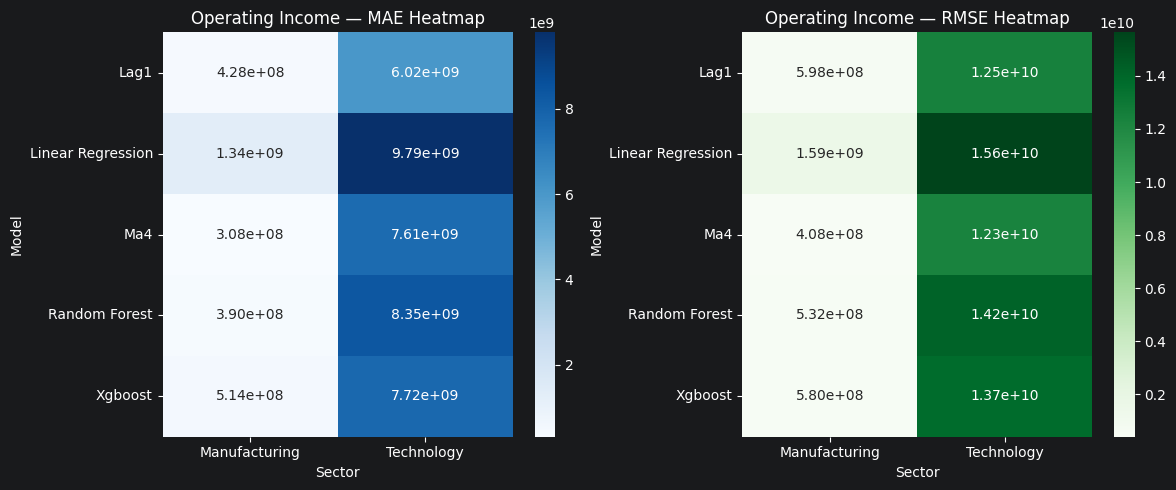

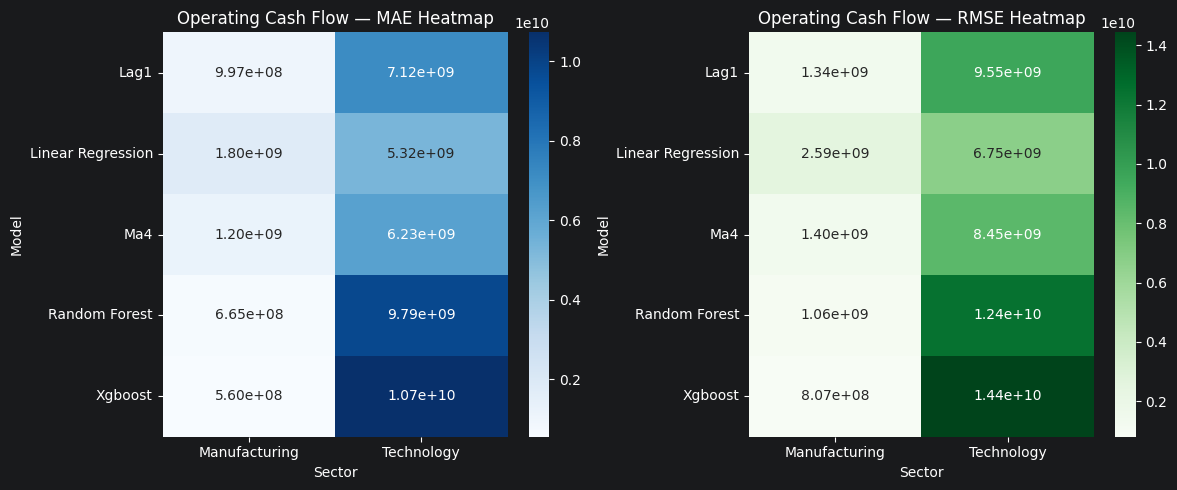

In [168]:
plot_mae_rmse_heatmap(oi_sector_results, "Operating Income")
plot_mae_rmse_heatmap(ocf_sector_results, "Operating Cash Flow")

In [169]:
def plot_r2_barchart(df, target_name):
    temp = df[df["Target"] == target_name].copy()

    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=temp,
        x="Model",
        y="R2",
        hue="Sector",
        palette="Set2"
    )

    plt.title(f"{target_name} — R² by Sector")
    plt.xticks(rotation=45)
    plt.ylabel("R²")
    plt.tight_layout()
    plt.show()

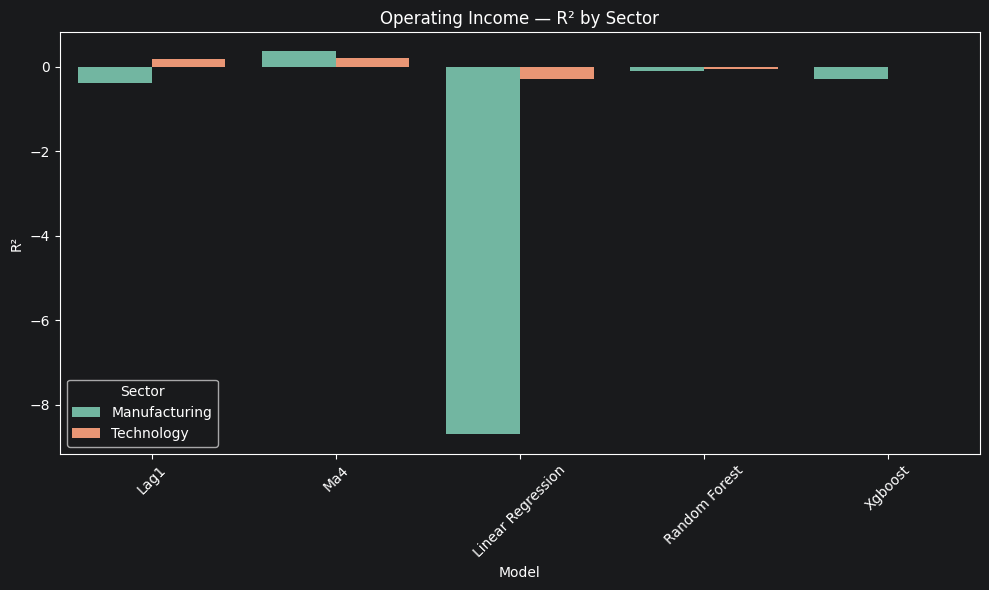

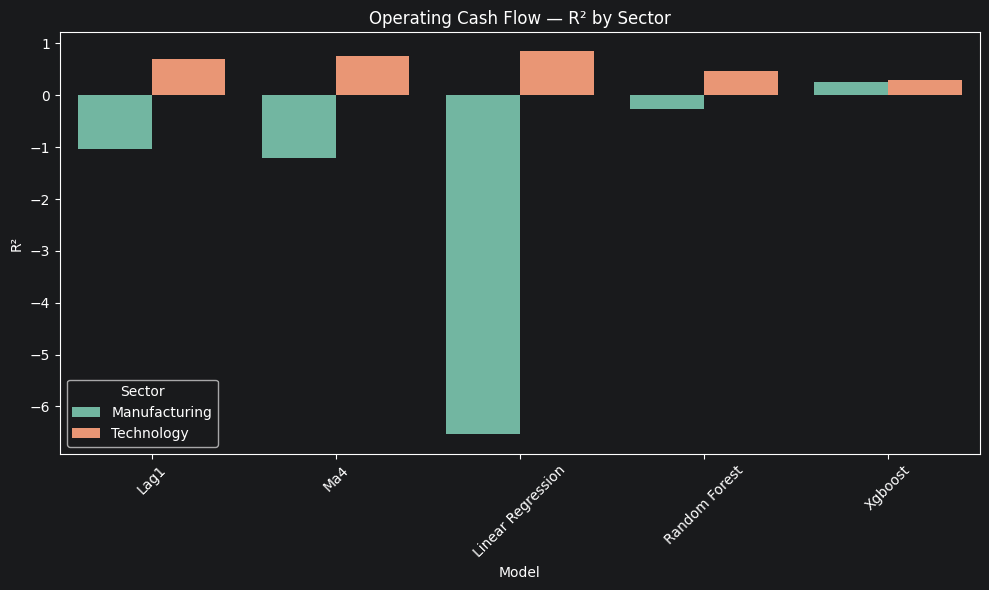

In [170]:
plot_r2_barchart(oi_sector_results, "Operating Income")
plot_r2_barchart(ocf_sector_results, "Operating Cash Flow")

In [171]:
company_sector_map = (
    panel_df[
        ["company_name", "sector"]
    ]
    .drop_duplicates()
)

oi_company_results_sector = (
    oi_company_results
    .merge(
        company_sector_map,
        left_on="Company",
        right_on="company_name",
        how="left"
    )
    .drop(columns="company_name")
)

ocf_company_results_sector = (
    ocf_company_results
    .merge(
        company_sector_map,
        left_on="Company",
        right_on="company_name",
        how="left"
    )
    .drop(columns="company_name")
)

In [172]:
def company_balanced_sector_summary(company_results):

    return (
        company_results
        .groupby(["sector", "Model"])
        .agg(
            Companies=("Company", "nunique"),
            Mean_Company_MAE=("MAE", "mean"),
            Median_Company_MAE=("MAE", "median"),
            Mean_Company_MASE=("MASE", "mean"),
            Median_Company_MASE=("MASE", "median")
        )
        .reset_index()
        .sort_values(
            ["sector", "Median_Company_MASE"]
        )
    )

In [173]:
oi_sector_company_balanced = (
    company_balanced_sector_summary(
        oi_company_results_sector
    )
)

ocf_sector_company_balanced = (
    company_balanced_sector_summary(
        ocf_company_results_sector
    )
)

display(oi_sector_company_balanced)
display(ocf_sector_company_balanced)

,sector,Model,Companies,Mean_Company_MAE,Median_Company_MAE,Mean_Company_MASE,Median_Company_MASE
0,Manufacturing,lag1,5,4.276400e+08,2.330000e+08,0.874685,0.469938
2,Manufacturing,ma4,5,3.083650e+08,2.171667e+08,0.844026,0.737058
3,Manufacturing,random_forest,5,3.897734e+08,2.861215e+08,1.506180,1.391084
4,Manufacturing,xgboost,5,5.144359e+08,5.005698e+08,2.162363,1.698920
1,Manufacturing,linear_regression,5,1.342628e+09,1.278026e+09,8.301440,5.784350
5,Technology,lag1,5,5.455900e+09,3.470000e+08,1.772442,0.212135
7,Technology,ma4,5,8.438492e+09,4.788167e+09,2.092395,0.391072
9,Technology,xgboost,5,8.186269e+09,7.612523e+09,2.609402,0.908812
8,Technology,random_forest,5,9.501865e+09,6.903957e+09,2.990069,1.459305
6,Technology,linear_regression,5,1.102527e+10,4.858428e+09,4.187506,1.625815


,sector,Model,Companies,Mean_Company_MAE,Median_Company_MAE,Mean_Company_MASE,Median_Company_MASE
2,Manufacturing,ma4,3,1.003800e+09,1.117750e+09,1.499771,1.191108
4,Manufacturing,xgboost,3,5.127860e+08,2.785581e+08,2.418963,1.305680
3,Manufacturing,random_forest,3,6.270421e+08,4.387005e+08,3.586275,1.529878
0,Manufacturing,lag1,3,8.464000e+08,6.540000e+08,1.635910,1.891586
1,Manufacturing,linear_regression,3,1.512222e+09,1.778804e+09,2.261036,1.895547
5,Technology,lag1,4,6.000000e+09,6.049500e+09,0.715819,0.621147
7,Technology,ma4,4,4.562812e+09,2.571000e+09,0.697196,0.652851
6,Technology,linear_regression,4,4.882510e+09,4.646791e+09,1.149002,0.788062
9,Technology,xgboost,4,7.902875e+09,4.761577e+09,1.056372,0.852700
8,Technology,random_forest,4,7.541186e+09,5.654893e+09,0.985041,0.867293


In [174]:
def missing_impact_check(df, target_col, feature_cols):
    feature_cols = [col for col in feature_cols if col in df.columns]

    lag1_col = f"{target_col}_lag1"
    ma4_col = f"{target_col}_ma4"

    baseline_cols = [
        col for col in [lag1_col, ma4_col]
        if col in df.columns
    ]

    cols_to_check = list(dict.fromkeys([target_col] + feature_cols + baseline_cols))

    temp = df[df[target_col].notna()].copy()

    summary = (
        temp[cols_to_check]
        .isna()
        .sum()
        .reset_index()
    )

    summary.columns = ["column", "missing_count"]
    summary["missing_ratio"] = summary["missing_count"] / len(temp)

    return summary.sort_values("missing_ratio", ascending=False)

Missing Data and Sample Diagnostics

This section examines how missing values affect the final modelling sample. Because of the imbalanced panel, useful observations may differ across target variables and feature sets.

In [175]:
missing_impact_check(panel_df, "OperatingIncome", oi_features)

,column,missing_count,missing_ratio
3,Revenue_lag1,58,0.201389
2,OperatingIncome_lag4,49,0.170139
1,OperatingIncome_lag1,32,0.111111
13,OperatingIncome_ma4,20,0.069444
5,inflation_rate_lag1,9,0.031250
4,Assets_lag1,9,0.031250
6,gdp_growth_lag1,9,0.031250
0,OperatingIncome,0,0.000000
8,fed_funds_rate_lag1,0,0.000000
7,unemployment_rate_lag1,0,0.000000


In [176]:
missing_impact_check(panel_df, "OperatingCashFlow_quarterly", ocf_features)

,column,missing_count,missing_ratio
1,OperatingCashFlow_quarterly_lag1,80,0.379147
3,Revenue_lag1,43,0.203791
13,OperatingCashFlow_quarterly_ma4,36,0.170616
2,OperatingIncome_lag1,24,0.113744
5,inflation_rate_lag1,8,0.037915
4,Assets_lag1,8,0.037915
6,gdp_growth_lag1,8,0.037915
0,OperatingCashFlow_quarterly,0,0.000000
8,fed_funds_rate_lag1,0,0.000000
7,unemployment_rate_lag1,0,0.000000


Sanity Checks,Data Limitations and Usability of Dataset

The diagnostic checks are used to identify unusual signs or values in selected balance-sheet and income-statement variables that may indicate problems in the data-processing steps. This provides an additional check on data quality before the models are estimated.

The sample diagnostics also compare the number of observations available for training and testing across the two forecasting tasks. Operating Income has a larger modelling sample than Operating Cash Flow. The OCF sample becomes particularly small in the 2025 test period, and some firms have no remaining test observations once the final feature requirements are applied. For this reason, the OCF findings should be interpreted cautiously and mainly as results from the available sample rather than as conclusions.

The usability of dataset shows the tested available variables. In the operating income, the situation is much better than operating cash flow. This example shows how important data availability is. Despite having less data to be tested in 2025, the operating cash flow comparison was made.
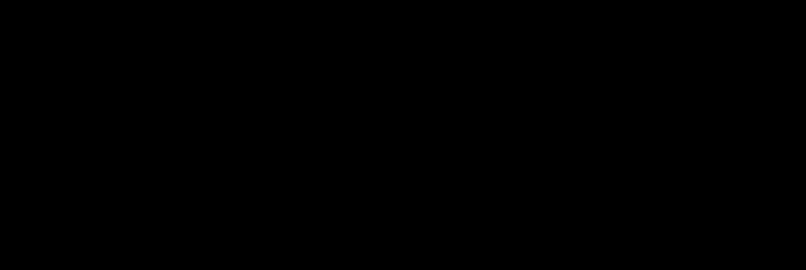
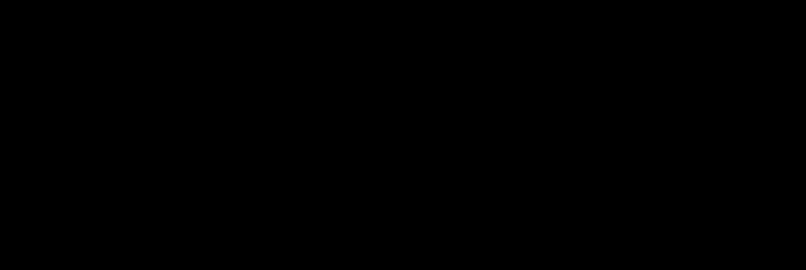
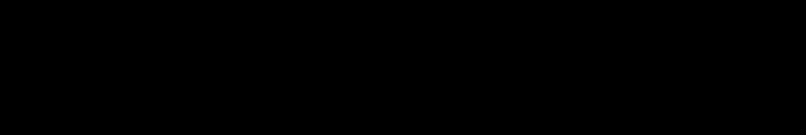

In [177]:
sanity_check = panel_df.groupby("company_name").agg(
    negative_assets=("Assets", lambda x: (x <= 0).sum()),
    zero_or_negative_revenue=("Revenue", lambda x: (x <= 0).sum()),
    zero_or_negative_liabilities=("Liabilities", lambda x: (x <= 0).sum())
).reset_index()

sanity_check

,company_name,negative_assets,zero_or_negative_revenue,zero_or_negative_liabilities
0,3M CO,0,1,0
1,ADOBE INC,0,0,0
2,APPLE INC,0,0,0
3,CUMMINS INC,0,0,0
4,FORTIVE CORP,0,1,0
5,IDEX CORP,0,3,0
6,ILLINOIS TOOL WORKS INC,0,0,0
7,INTEL CORP,0,2,0
8,MICROSOFT CORP,0,0,0
9,NVIDIA CORP,0,0,0


In [178]:
def model_sample_check(df, target_col, feature_cols):
    feature_cols = [col for col in feature_cols if col in df.columns]

    lag1_col = f"{target_col}_lag1"
    ma4_col = f"{target_col}_ma4"

    baseline_cols = [
        col for col in [lag1_col, ma4_col]
        if col in df.columns
    ]

    required_cols = (
        [target_col] +
        feature_cols +
        baseline_cols +
        ["dataset", "company_name", "ddate", "sector"]
    )

    required_cols = list(dict.fromkeys(required_cols))

    temp = df[required_cols].dropna().copy()

    return (
        temp
        .groupby("dataset")
        .size()
        .reset_index(name="observations_used")
    )

In [179]:
model_sample_check(panel_df, "OperatingIncome", oi_features)

,dataset,observations_used
0,test_2025,19
1,train,168


In [180]:
model_sample_check(panel_df, "OperatingCashFlow_quarterly", ocf_features)

,dataset,observations_used
0,test_2025,10
1,train,92


In [181]:
def test_sample_by_company(df, target_col, feature_cols):

    feature_cols = [
        col for col in feature_cols
        if col in df.columns
    ]

    required_cols = (
        ["company_name", "sector", "year", target_col]
        + feature_cols
    )

    temp = df[required_cols].copy()

    temp["usable_observation"] = (
        temp[[target_col] + feature_cols]
        .notna()
        .all(axis=1)
    )

    result = (
        temp[temp["year"] == 2025]
        .groupby(["sector", "company_name"])
        .agg(
            total_2025_rows=("year", "size"),
            usable_test_rows=("usable_observation", "sum")
        )
        .reset_index()
        .sort_values(["sector", "company_name"])
    )

    return result

In [182]:
oi_test_sample = test_sample_by_company(
    panel_df,
    "OperatingIncome",
    oi_features
)

oi_test_sample

,sector,company_name,total_2025_rows,usable_test_rows
0,Manufacturing,3M CO,3,2
1,Manufacturing,CUMMINS INC,3,2
2,Manufacturing,FORTIVE CORP,3,2
3,Manufacturing,IDEX CORP,3,2
4,Manufacturing,ILLINOIS TOOL WORKS INC,3,2
5,Technology,ADOBE INC,3,2
6,Technology,APPLE INC,3,2
7,Technology,INTEL CORP,3,2
8,Technology,MICROSOFT CORP,3,1
9,Technology,NVIDIA CORP,4,2


In [183]:
ocf_test_sample = test_sample_by_company(
    panel_df,
    "OperatingCashFlow_quarterly",
    ocf_features
)

ocf_test_sample

,sector,company_name,total_2025_rows,usable_test_rows
0,Manufacturing,3M CO,3,2
1,Manufacturing,CUMMINS INC,3,2
2,Manufacturing,FORTIVE CORP,3,0
3,Manufacturing,IDEX CORP,3,1
4,Manufacturing,ILLINOIS TOOL WORKS INC,3,0
5,Technology,ADOBE INC,3,1
6,Technology,APPLE INC,3,1
7,Technology,INTEL CORP,3,1
8,Technology,MICROSOFT CORP,3,2
9,Technology,NVIDIA CORP,4,0


The operating income results show that Random Forest delivers a strong overall R² and the lowest RMSE, while Lag-1 remains competitive in terms of MAE. XGBoost also performs well, but compared with models such as moving average and linear regression, its advantage is limited. These results suggest that machine-learning models can improve some aspects of Operating Income forecasting, although the improvement should be greater.

The operating cash flow results support simpler models. The moving average model achieves the lowest RMSE and the highest R², and Lag-1 also performs well. The machine learning models performed worse, as the small OCF sample and more volatile cash flow may have prevented them from performing at the intended level.

The sector-level analysis provides additional details to better analyze the comparison of models. Machine-learning models appear more competitive in some Manufacturing forecasts, whereas traditional and statistical approaches perform strongly in several Technology-sector comparisons. However, because the number of chosen sectors is small, readers should consider this experiment indicative; other experiments may yield different outcomes.
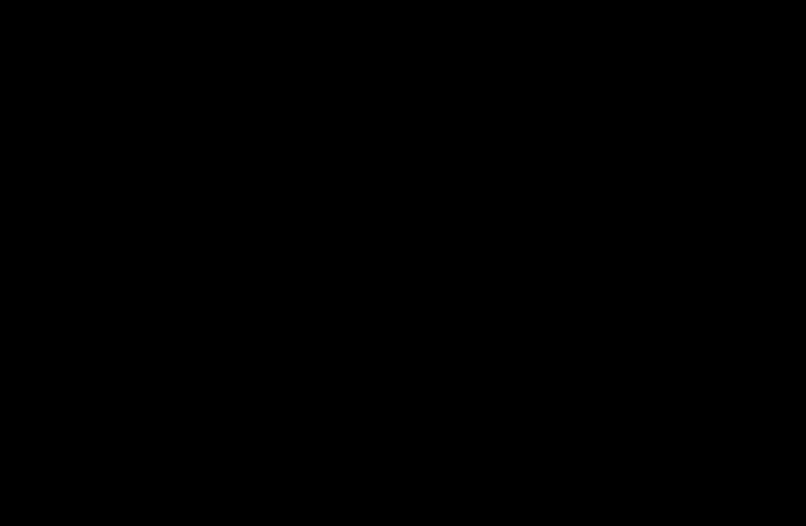